# Exploratory Data Analysis (EDA)

## Learning Behavior Analytics and Early Risk Signals in OULAD

**Purpose.** This streamlined version keeps only the analyses that directly support the final report, the at-risk branch, feature engineering, and Power BI.

**What was trimmed.**
- presentation-heavy blocks that repeated the same point,
- the separate module performance atlas,
- the standalone at-risk demographics dashboard,
- the report-ready insight table,
- secondary multivariate sections that overlapped with the at-risk block.

**Core storyline.**  
Data quality -> enrollment-level EDA base table -> learner and outcome profile -> engagement and timing -> VLE usage -> assessment and persistence -> at-risk signals -> handoff to modeling and Power BI.


## 1. Reproducible setup

Load packages, define helper functions, and prepare reusable utilities for a large clickstream-style dataset.


In [1]:
from __future__ import annotations

import warnings
from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from scipy.stats import chi2_contingency, kruskal
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12


_ORIGINAL_SEABORN_BARPLOT = sns.barplot
_ORIGINAL_SEABORN_COUNTPLOT = sns.countplot
_ORIGINAL_SEABORN_HISTPLOT = sns.histplot

def safe_barplot(*args, **kwargs):
    kwargs.setdefault("saturation", 1)
    if kwargs.get("hue") is None and kwargs.get("color") is None and kwargs.get("palette") is None:
        kwargs["color"] = "C0"
    return _ORIGINAL_SEABORN_BARPLOT(*args, **kwargs)

def safe_countplot(*args, **kwargs):
    kwargs.setdefault("saturation", 1)
    if kwargs.get("hue") is None and kwargs.get("color") is None and kwargs.get("palette") is None:
        kwargs["color"] = "C0"
    return _ORIGINAL_SEABORN_COUNTPLOT(*args, **kwargs)

def safe_histplot(*args, **kwargs):
    if kwargs.get("hue") is None and kwargs.get("color") is None and kwargs.get("palette") is None:
        kwargs["color"] = "C0"
    return _ORIGINAL_SEABORN_HISTPLOT(*args, **kwargs)

sns.barplot = safe_barplot
sns.countplot = safe_countplot
sns.histplot = safe_histplot

OUTCOME_ORDER = ["Distinction", "Pass", "Fail", "Withdrawn"]
AT_RISK_OUTCOMES = {"Fail", "Withdrawn"}
AT_RISK_LABELS = {0: "Non at-risk", 1: "At-risk"}

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")

ROOT = find_repo_root()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
NOTEBOOK_DIR = ROOT / "notebooks"

EXPECTED_FINAL_RESULTS = set(OUTCOME_ORDER)

def safe_load_csv(path: Path, **kwargs) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")
    return pd.read_csv(path, **kwargs)

def count_csv_rows(path: Path, chunksize: int = 500_000) -> int:
    total = 0
    for chunk in pd.read_csv(path, chunksize=chunksize):
        total += len(chunk)
    return total

def pct_table(series: pd.Series, dropna: bool = False, normalize: bool = True) -> pd.DataFrame:
    counts = series.value_counts(dropna=dropna)
    result = counts.rename("count").to_frame()
    if normalize:
        result["pct"] = result["count"] / result["count"].sum() * 100
    return result.reset_index().rename(columns={"index": series.name or "category"})

def grouped_numeric_summary(
    df: pd.DataFrame,
    group_col: str,
    value_cols: list[str],
    quantiles: tuple[float, ...] = (0.25, 0.5, 0.75),
) -> pd.DataFrame:
    summary = (
        df.groupby(group_col)[value_cols]
        .agg(["mean", "median", "std", "min", "max"])
    )
    quantile_frames = []
    for q in quantiles:
        q_df = df.groupby(group_col)[value_cols].quantile(q).unstack().rename(lambda col: f"{col}_q{int(q*100)}")
        quantile_frames.append(q_df)
    if quantile_frames:
        quantile_df = pd.concat(quantile_frames, axis=1)
        return summary.join(quantile_df)
    return summary

def format_pct(x: float) -> str:
    return f"{x:,.1f}%"

def add_bar_labels(ax, fmt: str = "{:,.0f}", rotation: int = 0) -> None:
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            if pd.isna(value):
                labels.append("")
            else:
                labels.append(fmt.format(value))
        ax.bar_label(container, labels=labels, padding=3, rotation=rotation, fontsize=10)

def plot_categorical_distribution(
    df: pd.DataFrame,
    column: str,
    order: list[str] | None = None,
    top_n: int | None = None,
    figsize: tuple[int, int] = (12, 5),
    title: str | None = None,
    rotate: int = 0,
) -> pd.Series:
    counts = df[column].astype("object").fillna("Missing").value_counts()
    if top_n is not None:
        counts = counts.head(top_n)
    if order is None:
        order = counts.index.tolist()
    plt.figure(figsize=figsize)
    ax = sns.countplot(data=df.assign(**{column: df[column].astype("object").fillna("Missing")}), x=column, order=order)
    ax.set_title(title or f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=rotate)
    add_bar_labels(ax)
    plt.tight_layout()
    return counts

def plot_numeric_distribution(
    series: pd.Series,
    title: str,
    xlabel: str,
    bins: int = 40,
    figsize: tuple[int, int] = (12, 5),
    log1p: bool = False,
) -> None:
    data = series.dropna()
    if log1p:
        data = np.log1p(data.clip(lower=0))
        xlabel = f"log1p({xlabel})"
    plt.figure(figsize=figsize)
    sns.histplot(data, bins=bins, kde=True)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()

def outcome_mix_table(
    df: pd.DataFrame,
    group_col: str,
    min_count: int = 0,
    normalize: bool = True,
    order: list[str] | None = None,
) -> pd.DataFrame:
    mix = pd.crosstab(df[group_col], df["final_result"])
    mix = mix.reindex(columns=OUTCOME_ORDER, fill_value=0)
    mix["n"] = mix.sum(axis=1)
    if min_count > 0:
        mix = mix[mix["n"] >= min_count]
    if order is not None:
        mix = mix.reindex(order)
    if normalize:
        pct = mix[OUTCOME_ORDER].div(mix[OUTCOME_ORDER].sum(axis=1), axis=0) * 100
        pct["n"] = mix["n"]
        return pct
    return mix

def plot_outcome_mix(
    df: pd.DataFrame,
    group_col: str,
    min_count: int = 0,
    normalize: bool = True,
    order: list[str] | None = None,
    figsize: tuple[int, int] = (12, 6),
    title: str | None = None,
    cmap: str = "YlGnBu",
):
    mix = outcome_mix_table(df, group_col, min_count=min_count, normalize=normalize, order=order)
    heat_data = mix[OUTCOME_ORDER]
    plt.figure(figsize=figsize)
    sns.heatmap(heat_data, annot=True, fmt=".1f" if normalize else ".0f", cmap=cmap)
    plt.title(title or f"Outcome mix by {group_col}")
    plt.xlabel("final_result")
    plt.ylabel(group_col)
    plt.tight_layout()
    return mix

def cramers_v(x: pd.Series, y: pd.Series) -> float:
    contingency = pd.crosstab(x, y)
    if contingency.empty:
        return np.nan
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.values.sum()
    if n == 0:
        return np.nan
    r, k = contingency.shape
    denom = min(k - 1, r - 1)
    if denom == 0:
        return np.nan
    return np.sqrt((chi2 / n) / denom)

def ensure_columns(df: pd.DataFrame, columns: list[str]) -> list[str]:
    return [col for col in columns if col in df.columns]

def share(series: pd.Series) -> float:
    if len(series) == 0:
        return np.nan
    return series.mean() * 100

def build_vle_aggregates(
    vle_path: Path,
    enrollment_outcomes: pd.DataFrame,
    vle_lookup: pd.DataFrame,
    cache_dir: Path | None = None,
    use_cache: bool = True,
    chunksize: int = 750_000,
):
    cache_dir = cache_dir or PROCESSED_DIR
    daily_cache = cache_dir / "_eda_daily_clicks_by_result.csv"
    activity_cache = cache_dir / "_eda_activity_clicks_by_result.csv"
    window_cache = cache_dir / "_eda_vle_window_features.csv"

    if use_cache and all(path.exists() for path in [daily_cache, activity_cache, window_cache]):
        daily = pd.read_csv(daily_cache)
        activity = pd.read_csv(activity_cache)
        window = pd.read_csv(window_cache)
        return daily, activity, window

    join_keys = enrollment_outcomes[["code_module", "code_presentation", "id_student", "final_result"]].drop_duplicates()
    activity_lookup = vle_lookup[["id_site", "activity_type"]].drop_duplicates()

    usecols = ["code_module", "code_presentation", "id_student", "id_site", "date", "sum_click"]
    dtypes = {
        "code_module": "string",
        "code_presentation": "string",
        "id_student": "int32",
        "id_site": "int32",
        "date": "int32",
        "sum_click": "float32",
    }

    day_frames = []
    daily_frames = []
    activity_frames = []

    for chunk in pd.read_csv(vle_path, usecols=usecols, dtype=dtypes, chunksize=chunksize):
        chunk = chunk.merge(join_keys, on=["code_module", "code_presentation", "id_student"], how="inner")
        chunk["sum_click"] = chunk["sum_click"].fillna(0)

        daily_frames.append(
            chunk.groupby(["date", "final_result"], observed=True)["sum_click"]
            .sum()
            .reset_index(name="total_clicks")
        )

        chunk_with_activity = chunk.merge(activity_lookup, on="id_site", how="left")
        chunk_with_activity["activity_type"] = chunk_with_activity["activity_type"].fillna("Unknown")

        activity_frames.append(
            chunk_with_activity.groupby(["activity_type", "final_result"], observed=True)["sum_click"]
            .sum()
            .reset_index(name="total_clicks")
        )

        # Collapse to one record per learner-day before counting active days.
        day_frames.append(
            chunk.groupby(["code_module", "code_presentation", "id_student", "date"], observed=True)["sum_click"]
            .sum()
            .reset_index()
        )

    daily = (
        pd.concat(daily_frames, ignore_index=True)
        .groupby(["date", "final_result"], as_index=False, observed=True)["total_clicks"]
        .sum()
        .sort_values(["final_result", "date"])
    )

    activity = (
        pd.concat(activity_frames, ignore_index=True)
        .groupby(["activity_type", "final_result"], as_index=False, observed=True)["total_clicks"]
        .sum()
        .sort_values(["activity_type", "final_result"])
    )

    day_level = (
        pd.concat(day_frames, ignore_index=True)
        .groupby(["code_module", "code_presentation", "id_student", "date"], as_index=False, observed=True)["sum_click"]
        .sum()
    )

    day_level["is_pre_start"] = (day_level["date"] < 0).astype(int)
    day_level["is_14d"] = day_level["date"].between(0, 14).astype(int)
    day_level["is_30d"] = day_level["date"].between(0, 30).astype(int)
    day_level["is_60d"] = day_level["date"].between(0, 60).astype(int)

    day_level["pre_start_clicks"] = np.where(day_level["date"] < 0, day_level["sum_click"], 0)
    day_level["clicks_14d"] = np.where(day_level["date"].between(0, 14), day_level["sum_click"], 0)
    day_level["clicks_30d"] = np.where(day_level["date"].between(0, 30), day_level["sum_click"], 0)
    day_level["clicks_60d"] = np.where(day_level["date"].between(0, 60), day_level["sum_click"], 0)

    window = (
        day_level.groupby(["code_module", "code_presentation", "id_student"], observed=True)
        .agg(
            pre_start_clicks=("pre_start_clicks", "sum"),
            clicks_14d=("clicks_14d", "sum"),
            clicks_30d=("clicks_30d", "sum"),
            clicks_60d=("clicks_60d", "sum"),
            total_active_days=("date", "size"),
            pre_start_active_days=("is_pre_start", "sum"),
            active_days_14=("is_14d", "sum"),
            active_days_30=("is_30d", "sum"),
        )
        .reset_index()
    )

    daily.to_csv(daily_cache, index=False)
    activity.to_csv(activity_cache, index=False)
    window.to_csv(window_cache, index=False)

    return daily, activity, window

def build_assessment_tables(
    enrollment_info: pd.DataFrame,
    assessments: pd.DataFrame,
    student_assessment: pd.DataFrame,
):
    assessment_catalog = (
        assessments.groupby(["code_module", "code_presentation"], observed=True)
        .agg(
            total_assessments_available=("id_assessment", "nunique"),
            total_weight=("weight", "sum"),
            first_assessment_date=("date", "min"),
            last_assessment_date=("date", "max"),
        )
        .reset_index()
    )

    assessment_perf = (
        student_assessment.merge(
            assessments,
            on="id_assessment",
            how="left",
            validate="many_to_one",
        )
        .merge(
            enrollment_info[["code_module", "code_presentation", "id_student", "final_result"]],
            on=["code_module", "code_presentation", "id_student"],
            how="inner",
        )
    )

    assessment_perf["submission_delay"] = assessment_perf["date_submitted"] - assessment_perf["date"]
    assessment_perf["is_late"] = (assessment_perf["submission_delay"] > 0).astype(int)
    assessment_perf["weighted_score_component"] = assessment_perf["score"] * assessment_perf["weight"].fillna(0) / 100
    assessment_perf["is_non_exam"] = assessment_perf["assessment_type"].ne("Exam").astype(int)
    assessment_perf["late_non_exam"] = np.where(
        assessment_perf["assessment_type"].ne("Exam"),
        assessment_perf["is_late"],
        np.nan,
    )
    assessment_perf["submission_delay_non_exam"] = np.where(
        assessment_perf["assessment_type"].ne("Exam"),
        assessment_perf["submission_delay"],
        np.nan,
    )

    enrollment_assessment = (
        assessment_perf.groupby(["code_module", "code_presentation", "id_student"], observed=True)
        .agg(
            assessment_submissions=("id_assessment", "size"),
            unique_assessments_submitted=("id_assessment", "nunique"),
            avg_score=("score", "mean"),
            median_score=("score", "median"),
            weighted_score_sum=("weighted_score_component", "sum"),
            avg_submission_delay=("submission_delay", "mean"),
            median_submission_delay=("submission_delay", "median"),
            late_submission_rate=("is_late", "mean"),
            avg_submission_delay_non_exam=("submission_delay_non_exam", "mean"),
            late_submission_rate_non_exam=("late_non_exam", "mean"),
            banked_submission_rate=("is_banked", "mean"),
        )
        .reset_index()
    )

    return assessment_catalog, assessment_perf, enrollment_assessment

print(f"Repository root: {ROOT}")
print(f"Processed data directory: {PROCESSED_DIR}")


Repository root: /Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/KHDL trong Mkt/Final Project
Processed data directory: /Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/KHDL trong Mkt/Final Project/data/processed


## 2. Data inventory

Review the role, grain, and key structure of each input table before moving into EDA.


In [2]:
dataset_meta = OrderedDict({
    "student_info_clean": {
        "filename": "student_info_clean.csv",
        "role": "Cleaned learner profile with demographics and final_result. Intended enrollment-level outcome table, but must be audited for key integrity.",
        "keys": ["code_module", "code_presentation", "id_student"],
        "load_mode": "full",
    },
    "student_registration_clean": {
        "filename": "student_registration_clean.csv",
        "role": "Learner registration and unregistration timing by module-presentation.",
        "keys": ["code_module", "code_presentation", "id_student"],
        "load_mode": "full",
    },
    "student_vle_clean": {
        "filename": "student_vle_clean.csv",
        "role": "Large clickstream table at learner-resource-day grain. Used via chunked aggregation only.",
        "keys": ["code_module", "code_presentation", "id_student", "id_site", "date"],
        "load_mode": "lazy",
    },
    "assessments_clean": {
        "filename": "assessments_clean.csv",
        "role": "Assessment catalog with type, schedule, and weight.",
        "keys": ["id_assessment"],
        "load_mode": "full",
    },
    "student_assessment_clean": {
        "filename": "student_assessment_clean.csv",
        "role": "Assessment submissions and scores by learner.",
        "keys": ["id_assessment", "id_student"],
        "load_mode": "full",
    },
    "vle_clean": {
        "filename": "vle_clean.csv",
        "role": "VLE resource metadata including activity_type and release weeks.",
        "keys": ["id_site", "code_module", "code_presentation"],
        "load_mode": "full",
    },
    "courses": {
        "filename": "courses.csv",
        "role": "Course presentation metadata including presentation length.",
        "keys": ["code_module", "code_presentation"],
        "load_mode": "full",
    },
    "student_profile": {
        "filename": "student_profile.csv",
        "role": "Learner-level profile summary across modules and presentations.",
        "keys": ["id_student"],
        "load_mode": "full",
    },
    "student_vle_summary": {
        "filename": "student_vle_summary.csv",
        "role": "Enrollment-level VLE summary with total clicks and first/last activity dates.",
        "keys": ["code_module", "code_presentation", "id_student"],
        "load_mode": "full",
    },
    "assessment_performance": {
        "filename": "assessment_performance.csv",
        "role": "Joined assessment submissions with outcomes. Useful for auditing, but re-built later to protect enrollment-level integrity.",
        "keys": ["id_assessment", "id_student", "code_module", "code_presentation"],
        "load_mode": "full",
    },
    "student_course_registration": {
        "filename": "student_course_registration.csv",
        "role": "Joined registration table with selected learner profile fields and outcome labels.",
        "keys": ["code_module", "code_presentation", "id_student"],
        "load_mode": "full",
    },
})

tables = {}
inventory_records = []

for name, meta in dataset_meta.items():
    path = PROCESSED_DIR / meta["filename"]
    if meta["load_mode"] == "lazy":
        sample = safe_load_csv(path, nrows=5)
        dtypes = sample.dtypes.astype(str).to_dict()
        shape_rows = count_csv_rows(path)
        tables[name] = {"path": path, "sample": sample}
        columns = sample.columns.tolist()
    else:
        df = safe_load_csv(path)
        tables[name] = df
        dtypes = df.dtypes.astype(str).to_dict()
        shape_rows = len(df)
        columns = df.columns.tolist()

    inventory_records.append(
        {
            "dataset": name,
            "rows": shape_rows,
            "columns": len(columns),
            "load_mode": meta["load_mode"],
            "key_identifiers": ", ".join(meta["keys"]),
            "role": meta["role"],
        }
    )

inventory_df = pd.DataFrame(inventory_records).sort_values("rows", ascending=False)
display(inventory_df)

,dataset,rows,columns,load_mode,key_identifiers,role
2,student_vle_clean,10655280,6,lazy,"code_module, code_presentation, id_student, id...",Large clickstream table at learner-resource-da...
4,student_assessment_clean,173912,5,full,"id_assessment, id_student",Assessment submissions and scores by learner.
9,assessment_performance,173912,10,full,"id_assessment, id_student, code_module, code_p...",Joined assessment submissions with outcomes. U...
1,student_registration_clean,32593,5,full,"code_module, code_presentation, id_student",Learner registration and unregistration timing...
10,student_course_registration,32593,10,full,"code_module, code_presentation, id_student",Joined registration table with selected learne...
8,student_vle_summary,29228,8,full,"code_module, code_presentation, id_student",Enrollment-level VLE summary with total clicks...
0,student_info_clean,28785,12,full,"code_module, code_presentation, id_student",Cleaned learner profile with demographics and ...
7,student_profile,28785,14,full,id_student,Learner-level profile summary across modules a...
5,vle_clean,6364,6,full,"id_site, code_module, code_presentation",VLE resource metadata including activity_type ...
3,assessments_clean,206,6,full,id_assessment,"Assessment catalog with type, schedule, and we..."


In [3]:
for name, meta in dataset_meta.items():
    display(Markdown(f"### `{meta['filename']}`"))
    display(Markdown(meta["role"]))

    if meta["load_mode"] == "lazy":
        df_preview = tables[name]["sample"].copy()
        dtypes = df_preview.dtypes.astype(str).rename("dtype").reset_index().rename(columns={"index": "column"})
        shape_text = f"Shape: approximately **{inventory_df.loc[inventory_df['dataset'].eq(name), 'rows'].iloc[0]:,} rows × {len(df_preview.columns)} columns** (preview loaded lazily)."
    else:
        df_preview = tables[name].head(3).copy()
        dtypes = tables[name].dtypes.astype(str).rename("dtype").reset_index().rename(columns={"index": "column"})
        shape_text = f"Shape: **{tables[name].shape[0]:,} rows × {tables[name].shape[1]} columns**."

    display(Markdown(shape_text))
    key_flags = dtypes["column"].isin(meta["keys"]).map({True: "Yes", False: ""})
    schema_view = dtypes.assign(key_identifier=key_flags)
    display(schema_view)
    display(df_preview)

### `student_info_clean.csv`

Cleaned learner profile with demographics and final_result. Intended enrollment-level outcome table, but must be audited for key integrity.

Shape: **28,785 rows × 12 columns**.

,column,dtype,key_identifier
0,code_module,object,Yes
1,code_presentation,object,Yes
2,id_student,int64,Yes
3,gender,object,
4,region,object,
5,highest_education,object,
6,imd_band,object,
7,age_band,object,
8,num_of_prev_attempts,int64,
9,studied_credits,int64,


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn


...

### `student_course_registration.csv`

Joined registration table with selected learner profile fields and outcome labels.

Shape: **32,593 rows × 10 columns**.

,column,dtype,key_identifier
0,code_module,object,Yes
1,code_presentation,object,Yes
2,id_student,int64,Yes
3,date_registration,float64,
4,date_unregistration,float64,
5,gender,object,
6,region,object,
7,highest_education,object,
8,age_band,object,
9,final_result,object,


,code_module,code_presentation,id_student,date_registration,date_unregistration,gender,region,highest_education,age_band,final_result
0,AAA,2013J,11391,-159.000,NaN,M,East Anglian Region,HE Qualification,55<=,Pass
1,AAA,2013J,28400,-53.000,NaN,F,Scotland,HE Qualification,35-55,Pass
2,AAA,2013J,30268,-92.000,12.000,F,North Western Region,A Level or Equivalent,35-55,Withdrawn


### 2.1 Quick sanity checks

Check missingness, duplicate risk, key consistency, and outcome-label integrity so later insights stay defensible.


In [4]:
student_info_clean = tables["student_info_clean"].copy()
student_registration_clean = tables["student_registration_clean"].copy()
assessments_clean = tables["assessments_clean"].copy()
student_assessment_clean = tables["student_assessment_clean"].copy()
vle_clean = tables["vle_clean"].copy()
courses = tables["courses"].copy()
student_profile = tables["student_profile"].copy()
student_vle_summary = tables["student_vle_summary"].copy()
assessment_performance = tables["assessment_performance"].copy()
student_course_registration = tables["student_course_registration"].copy()
student_vle_path = tables["student_vle_clean"]["path"]

key_map = {
    "student_info_clean": ["code_module", "code_presentation", "id_student"],
    "student_registration_clean": ["code_module", "code_presentation", "id_student"],
    "assessments_clean": ["id_assessment"],
    "student_assessment_clean": ["id_assessment", "id_student"],
    "vle_clean": ["id_site", "code_module", "code_presentation"],
    "courses": ["code_module", "code_presentation"],
    "student_profile": ["id_student"],
    "student_vle_summary": ["code_module", "code_presentation", "id_student"],
    "assessment_performance": ["id_assessment", "id_student", "code_module", "code_presentation"],
    "student_course_registration": ["code_module", "code_presentation", "id_student"],
}

small_tables = {
    "student_info_clean": student_info_clean,
    "student_registration_clean": student_registration_clean,
    "assessments_clean": assessments_clean,
    "student_assessment_clean": student_assessment_clean,
    "vle_clean": vle_clean,
    "courses": courses,
    "student_profile": student_profile,
    "student_vle_summary": student_vle_summary,
    "assessment_performance": assessment_performance,
    "student_course_registration": student_course_registration,
}

sanity_records = []
for name, df in small_tables.items():
    missing_cells = int(df.isna().sum().sum())
    missing_pct = missing_cells / (df.shape[0] * max(df.shape[1], 1)) * 100
    key_cols = key_map.get(name, [])
    duplicate_keys = int(df.duplicated(subset=key_cols).sum()) if key_cols else np.nan
    sanity_records.append(
        {
            "dataset": name,
            "rows": len(df),
            "duplicate_rows": int(df.duplicated().sum()),
            "duplicate_key_rows": duplicate_keys,
            "missing_cells": missing_cells,
            "missing_pct": missing_pct,
        }
    )

sanity_df = pd.DataFrame(sanity_records).sort_values(["duplicate_key_rows", "missing_pct"], ascending=[False, False])
display(sanity_df)

,dataset,rows,duplicate_rows,duplicate_key_rows,missing_cells,missing_pct
1,student_registration_clean,32593,0,0,22542,13.832
9,student_course_registration,32593,0,0,22542,6.916
0,student_info_clean,28785,0,0,0,0.000
2,assessments_clean,206,0,0,0,0.000
3,student_assessment_clean,173912,0,0,0,0.000
4,vle_clean,6364,0,0,0,0.000
5,courses,22,0,0,0,0.000
6,student_profile,28785,0,0,0,0.000
7,student_vle_summary,29228,0,0,0,0.000
8,assessment_performance,173912,0,0,0,0.000


In [5]:
missing_profile = (
    pd.DataFrame({name: df.isna().mean().mul(100) for name, df in small_tables.items()})
    .stack()
    .reset_index()
    .rename(columns={"level_0": "column", "level_1": "dataset", 0: "missing_pct"})
    .sort_values("missing_pct", ascending=False)
)

display(missing_profile.query("missing_pct > 0").head(25))

range_checks = pd.DataFrame([
    {
        "check": "studied_credits",
        "minimum": student_info_clean["studied_credits"].min(),
        "maximum": student_info_clean["studied_credits"].max(),
        "expected": "Positive numeric workload values",
    },
    {
        "check": "num_of_prev_attempts",
        "minimum": student_info_clean["num_of_prev_attempts"].min(),
        "maximum": student_info_clean["num_of_prev_attempts"].max(),
        "expected": "Non-negative attempt count",
    },
    {
        "check": "assessment score",
        "minimum": student_assessment_clean["score"].min(),
        "maximum": student_assessment_clean["score"].max(),
        "expected": "0 to 100",
    },
    {
        "check": "assessment weight",
        "minimum": assessments_clean["weight"].min(),
        "maximum": assessments_clean["weight"].max(),
        "expected": "Non-negative, course-specific weighting",
    },
    {
        "check": "date_registration",
        "minimum": student_registration_clean["date_registration"].min(),
        "maximum": student_registration_clean["date_registration"].max(),
        "expected": "Can be negative when students register before module start",
    },
    {
        "check": "date_unregistration",
        "minimum": student_registration_clean["date_unregistration"].min(),
        "maximum": student_registration_clean["date_unregistration"].max(),
        "expected": "Optional; often populated for withdrawn learners",
    },
    {
        "check": "module_presentation_length",
        "minimum": courses["module_presentation_length"].min(),
        "maximum": courses["module_presentation_length"].max(),
        "expected": "Positive module duration in days",
    },
])

display(range_checks)

category_checks = {
    "final_result": sorted(student_info_clean["final_result"].dropna().unique().tolist()),
    "gender": sorted(student_info_clean["gender"].dropna().unique().tolist()),
    "disability": sorted(student_info_clean["disability"].dropna().unique().tolist()),
    "assessment_type": sorted(assessments_clean["assessment_type"].dropna().unique().tolist()),
}

for category, values in category_checks.items():
    display(Markdown(f"**Unique values for `{category}`**: {values}"))

,column,dataset,missing_pct
30,date_unregistration,student_registration_clean,69.162
31,date_unregistration,student_course_registration,69.162


,check,minimum,maximum,expected
0,studied_credits,30.000,655.000,Positive numeric workload values
1,num_of_prev_attempts,0.000,6.000,Non-negative attempt count
2,assessment score,0.000,100.000,0 to 100
3,assessment weight,0.000,100.000,"Non-negative, course-specific weighting"
4,date_registration,-322.000,167.000,Can be negative when students register before ...
5,date_unregistration,-317.000,444.000,Optional; often populated for withdrawn learners
6,module_presentation_length,234.000,269.000,Positive module duration in days


**Unique values for `final_result`**: ['Distinction', 'Fail', 'Pass', 'Withdrawn']

**Unique values for `gender`**: ['F', 'M']

**Unique values for `disability`**: ['N', 'Y']

**Unique values for `assessment_type`**: ['CMA', 'Exam', 'TMA']

In [6]:
key_consistency = []

def missing_key_rate(left: pd.DataFrame, right: pd.DataFrame, on: list[str]) -> float:
    merged = left[on].drop_duplicates().merge(right[on].drop_duplicates(), on=on, how="left", indicator=True)
    return (merged["_merge"] == "left_only").mean() * 100

key_consistency.append({
    "relationship": "student_registration -> courses",
    "missing_key_pct": missing_key_rate(student_registration_clean, courses, ["code_module", "code_presentation"]),
})
key_consistency.append({
    "relationship": "student_vle_summary -> student_registration",
    "missing_key_pct": missing_key_rate(student_vle_summary, student_registration_clean, ["code_module", "code_presentation", "id_student"]),
})
key_consistency.append({
    "relationship": "student_course_registration -> student_registration",
    "missing_key_pct": missing_key_rate(student_course_registration, student_registration_clean, ["code_module", "code_presentation", "id_student"]),
})
key_consistency.append({
    "relationship": "assessments_clean -> courses",
    "missing_key_pct": missing_key_rate(assessments_clean, courses, ["code_module", "code_presentation"]),
})
key_consistency.append({
    "relationship": "vle_clean -> courses",
    "missing_key_pct": missing_key_rate(vle_clean, courses, ["code_module", "code_presentation"]),
})

key_consistency_df = pd.DataFrame(key_consistency)
display(key_consistency_df)

,relationship,missing_key_pct
0,student_registration -> courses,0.000
1,student_vle_summary -> student_registration,0.000
2,student_course_registration -> student_registr...,0.000
3,assessments_clean -> courses,0.000
4,vle_clean -> courses,0.000


In [7]:
raw_student_info_path = RAW_DIR / "studentInfo.csv"
raw_student_info = safe_load_csv(raw_student_info_path) if raw_student_info_path.exists() else None

integrity_notes = []

if raw_student_info is not None:
    raw_student_info = raw_student_info.drop_duplicates(subset=["code_module", "code_presentation", "id_student"]).copy()
    raw_rows = len(raw_student_info)
    processed_rows = len(student_info_clean)

    duplicate_student_collisions = raw_student_info.groupby("id_student").size().gt(1).sum()
    conflicting_outcomes = raw_student_info.groupby("id_student")["final_result"].nunique().gt(1).sum()

    processed_join = (
        student_registration_clean[["code_module", "code_presentation", "id_student"]]
        .merge(
            student_info_clean[["id_student", "final_result"]],
            on="id_student",
            how="left",
        )
        .rename(columns={"final_result": "processed_final_result"})
    )

    raw_join = raw_student_info[["code_module", "code_presentation", "id_student", "final_result"]].rename(
        columns={"final_result": "raw_final_result"}
    )

    comparison = processed_join.merge(
        raw_join,
        on=["code_module", "code_presentation", "id_student"],
        how="inner",
    )
    enrollment_mismatch_count = int((comparison["processed_final_result"] != comparison["raw_final_result"]).sum())

    assessment_join_processed = (
        student_assessment_clean[["id_assessment", "id_student"]]
        .merge(assessments_clean[["id_assessment", "code_module", "code_presentation"]], on="id_assessment", how="left")
        .merge(student_info_clean[["id_student", "final_result"]], on="id_student", how="left")
        .rename(columns={"final_result": "processed_final_result"})
    )

    assessment_join_raw = (
        student_assessment_clean[["id_assessment", "id_student"]]
        .merge(assessments_clean[["id_assessment", "code_module", "code_presentation"]], on="id_assessment", how="left")
        .merge(
            raw_student_info[["code_module", "code_presentation", "id_student", "final_result"]].rename(columns={"final_result": "raw_final_result"}),
            on=["code_module", "code_presentation", "id_student"],
            how="left",
        )
    )

    assessment_comparison = assessment_join_processed.merge(
        assessment_join_raw[["id_assessment", "id_student", "code_module", "code_presentation", "raw_final_result"]],
        on=["id_assessment", "id_student", "code_module", "code_presentation"],
        how="inner",
    )
    assessment_mismatch_count = int(
        (assessment_comparison["processed_final_result"] != assessment_comparison["raw_final_result"]).sum()
    )

    integrity_audit = pd.DataFrame([
        {
            "metric": "Rows in raw studentInfo.csv",
            "value": raw_rows,
        },
        {
            "metric": "Rows in processed student_info_clean.csv",
            "value": processed_rows,
        },
        {
            "metric": "Enrollment rows dropped by processed deduplication",
            "value": raw_rows - processed_rows,
        },
        {
            "metric": "Students with multiple enrollments",
            "value": int(duplicate_student_collisions),
        },
        {
            "metric": "Students with >1 unique final_result",
            "value": int(conflicting_outcomes),
        },
        {
            "metric": "Enrollment labels that would be wrong via id_student-only join",
            "value": enrollment_mismatch_count,
        },
        {
            "metric": "Assessment rows that would be wrong via id_student-only join",
            "value": assessment_mismatch_count,
        },
    ])
    display(integrity_audit)

    integrity_notes = [
        f"`student_info_clean.csv` contains {processed_rows:,} rows, but raw `studentInfo.csv` contains {raw_rows:,} enrollment rows.",
        f"{duplicate_student_collisions:,} learners appear in more than one enrollment, and {conflicting_outcomes:,} learners have multiple distinct `final_result` values across enrollments.",
        f"If outcomes are joined back using `id_student` only, {enrollment_mismatch_count:,} registration rows and {assessment_mismatch_count:,} assessment rows receive the wrong label.",
        "For the rest of this notebook, processed tables remain the default source, but the enrollment-level outcome grain is restored from raw `studentInfo.csv` when available.",
    ]
else:
    integrity_notes = [
        "Raw `studentInfo.csv` is unavailable, so the notebook falls back to `student_info_clean.csv`.",
        "This fallback is still runnable, but enrollment-level outcome integrity should be rechecked before final modeling.",
    ]


,metric,value
0,Rows in raw studentInfo.csv,32593
1,Rows in processed student_info_clean.csv,28785
2,Enrollment rows dropped by processed deduplica...,3808
3,Students with multiple enrollments,3538
4,Students with >1 unique final_result,1929
5,Enrollment labels that would be wrong via id_s...,1997
6,Assessment rows that would be wrong via id_stu...,12094


**Sanity check interpretation**

- `student_info_clean.csv` contains 28,785 rows, but raw `studentInfo.csv` contains 32,593 enrollment rows.
- 3,538 learners appear in more than one enrollment, and 1,929 learners have multiple distinct `final_result` values across enrollments.
- If outcomes are joined back using `id_student` only, 1,997 registration rows and 12,094 assessment rows receive the wrong label.
- For the rest of this notebook, processed tables remain the default source, but the enrollment-level outcome grain is restored from raw `studentInfo.csv` when available.


## 3. Build the canonical EDA base table

Create one enrollment-level analytical table that can be reused for EDA, feature engineering, recommendation design, and Power BI.


In [8]:
if raw_student_info is not None:
    enrollment_info = raw_student_info.copy()
    outcome_source = "raw studentInfo.csv (used only to preserve the correct enrollment-level outcome grain)"
else:
    enrollment_info = student_info_clean.copy()
    outcome_source = "student_info_clean.csv (fallback because raw studentInfo.csv was unavailable)"

enrollment_info = enrollment_info.drop_duplicates(subset=["code_module", "code_presentation", "id_student"]).copy()
enrollment_info["imd_band"] = enrollment_info["imd_band"].fillna("Unknown")
enrollment_info["final_result"] = pd.Categorical(enrollment_info["final_result"], categories=OUTCOME_ORDER, ordered=True)
enrollment_info["at_risk_eda"] = enrollment_info["final_result"].isin(AT_RISK_OUTCOMES).astype(int)
enrollment_info["at_risk_label"] = enrollment_info["at_risk_eda"].map(AT_RISK_LABELS)


**Outcome source used for the master EDA table:** raw studentInfo.csv (used only to preserve the correct enrollment-level outcome grain)

Enrollment rows in master outcome table: 32,593


In [9]:
daily_clicks_by_result, activity_clicks_by_result, vle_window_features = build_vle_aggregates(
    vle_path=student_vle_path,
    enrollment_outcomes=enrollment_info,
    vle_lookup=vle_clean,
    cache_dir=PROCESSED_DIR,
    use_cache=True,
)

assessment_catalog, assessment_perf_corrected, assessment_enrollment = build_assessment_tables(
    enrollment_info=enrollment_info,
    assessments=assessments_clean,
    student_assessment=student_assessment_clean,
)

profile_cols = ensure_columns(student_profile, ["id_student", "num_modules", "num_presentations"])

eda_base = (
    enrollment_info
    .merge(student_registration_clean, on=["code_module", "code_presentation", "id_student"], how="left")
    .merge(courses, on=["code_module", "code_presentation"], how="left")
    .merge(student_vle_summary, on=["code_module", "code_presentation", "id_student"], how="left")
    .merge(vle_window_features, on=["code_module", "code_presentation", "id_student"], how="left")
    .merge(student_profile[profile_cols].drop_duplicates("id_student"), on="id_student", how="left")
    .merge(assessment_catalog, on=["code_module", "code_presentation"], how="left")
    .merge(assessment_enrollment, on=["code_module", "code_presentation", "id_student"], how="left")
)

fill_zero_cols = [
    "total_clicks",
    "avg_clicks",
    "max_clicks_per_day",
    "pre_start_clicks",
    "clicks_14d",
    "clicks_30d",
    "clicks_60d",
    "total_active_days",
    "pre_start_active_days",
    "active_days_14",
    "active_days_30",
    "assessment_submissions",
    "unique_assessments_submitted",
    "weighted_score_sum",
]
for col in fill_zero_cols:
    if col in eda_base.columns:
        eda_base[col] = eda_base[col].fillna(0)

rate_fill_cols = ["late_submission_rate", "late_submission_rate_non_exam", "banked_submission_rate"]
for col in rate_fill_cols:
    if col in eda_base.columns:
        eda_base[col] = eda_base[col].fillna(0)

eda_base["has_vle_activity"] = (eda_base["total_clicks"] > 0).astype(int)
eda_base["has_assessment_submission"] = (eda_base["assessment_submissions"] > 0).astype(int)
eda_base["active_duration_days"] = (
    (eda_base["last_activity_date"] - eda_base["first_activity_date"]).fillna(0).clip(lower=0)
)
eda_base["clicks_per_active_day"] = np.where(
    eda_base["total_active_days"] > 0,
    eda_base["total_clicks"] / eda_base["total_active_days"],
    0,
)
eda_base["engagement_recency_from_end"] = np.where(
    eda_base["last_activity_date"].notna(),
    eda_base["module_presentation_length"] - eda_base["last_activity_date"],
    eda_base["module_presentation_length"],
)
eda_base["assessment_completion_ratio"] = np.where(
    eda_base["total_assessments_available"] > 0,
    eda_base["unique_assessments_submitted"] / eda_base["total_assessments_available"],
    0,
)
eda_base["withdrawal_before_end"] = (
    eda_base["date_unregistration"].notna()
    & (eda_base["date_unregistration"] < eda_base["module_presentation_length"])
).astype(int)
eda_base["registered_before_start_days"] = -eda_base["date_registration"]
eda_base["engaged_pre_start"] = (eda_base["pre_start_clicks"] > 0).astype(int)
eda_base["early_active_flag_14d"] = (eda_base["clicks_14d"] > 0).astype(int)
eda_base["clicks_15_30"] = (eda_base["clicks_30d"] - eda_base["clicks_14d"]).clip(lower=0)
eda_base["clicks_31_60"] = (eda_base["clicks_60d"] - eda_base["clicks_30d"]).clip(lower=0)
eda_base["clicks_post60"] = (eda_base["total_clicks"] - eda_base["clicks_60d"]).clip(lower=0)

studied_credit_bins = [0, 60, 90, 120, 180, 240, 360, np.inf]
studied_credit_labels = ["<=60", "61-90", "91-120", "121-180", "181-240", "241-360", "360+"]
eda_base["studied_credits_band"] = pd.cut(
    eda_base["studied_credits"],
    bins=studied_credit_bins,
    labels=studied_credit_labels,
    include_lowest=True,
)

eda_base["final_result"] = pd.Categorical(eda_base["final_result"], categories=OUTCOME_ORDER, ordered=True)

print(f"Master EDA table shape: {eda_base.shape[0]:,} rows × {eda_base.shape[1]} columns")
display(eda_base.head())

Master EDA table shape: 32,593 rows × 61 columns


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,at_risk_eda,at_risk_label,date_registration,date_unregistration,module_presentation_length,total_clicks,avg_clicks,max_clicks_per_day,first_activity_date,last_activity_date,pre_start_clicks,clicks_14d,clicks_30d,clicks_60d,total_active_days,pre_start_active_days,active_days_14,active_days_30,num_modules,num_presentations,total_assessments_available,total_weight,first_assessment_date,last_assessment_date,assessment_submissions,unique_assessments_submitted,avg_score,median_score,weighted_score_sum,avg_submission_delay,median_submission_delay,late_submission_rate,avg_submission_delay_non_exam,late_submission_rate_non_exam,banked_submission_rate,has_vle_activity,has_assessment_submission,active_duration_days,clicks_per_active_day,engagement_recency_from_end,assessment_completion_ratio,withdrawal_before_end,registered_before_start_days,engaged_pre_start,early_active_flag_14d,clicks_15_30,clicks_31_60,clicks_post60,studied_credits_band
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,Non at-risk,-159.000,NaN,268,934.000,4.765,76.000,-5.000,253.000,98.000,203.000,326.000,431.000,40.000,1.000,5.000,9.000,1,1,6,200.000,0,215,5.000,5.000,82.000,82.000,82.400,-1.800,-2.000,0.000,-1.800,0.000,0.000,1,1,258.000,23.350,15.000,0.833,0,159.000,1,1,123.000,105.000,503.000,181-240
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,Non at-risk,-53.000,NaN,268,"1,435.000",3.337,23.000,-10.000,239.000,215.000,241.000,403.000,454.000,80.000,7.000,7.000,12.000,1,1,6,200.000,0,215,5.000,5.000,66.400,68.000,65.400,0.000,-2.000,0.400,0.000,0.400,0.000,1,1,249.000,17.938,29.000,0.833,0,53.000,1,1,162.000,51.000,981.000,<=60
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,At-risk,-92.000,12.000,268,281.000,3.697,23.000,-10.000,12.000,102.000,179.000,179.000,179.000,12.000,6.000,6.000,6.000,1,1,6,200.000,0,215,0.000,0.000,NaN,NaN,0.000,NaN,NaN,0.000,NaN,0.000,0.000,1,0,22.000,23.417,256.000,0.000,1,92.000,1,1,0.000,0.000,102.000,<=60
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0,Non at-risk,-52.000,NaN,268,"2,158.000",3.255,22.000,-10.000,264.000,169.000,180.000,371.000,647.000,123.000,5.000,8.000,19.000,1,1,6,200.000,0,215,5.000,5.000,76.000,74.000,76.300,-2.000,-2.000,0.000,-2.000,0.000,0.000,1,1,274.000,17.545,4.000,0.833,0,52.000,1,1,191.000,276.000,"1,511.000",<=60
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0,Non at-risk,-176.000,NaN,268,"1,034.000",2.938,22.000,-10.000,247.000,295.000,177.000,272.000,310.000,70.000,8.000,9.000,16.000,1,1,6,200.000,0,215,5.000,5.000,54.400,63.000,55.000,11.400,7.000,1.000,11.400,1.000,0.000,1,1,257.000,14.771,21.000,0.833,0,176.000,1,1,95.000,38.000,724.000,<=60


## 4. Executive overview

Start with the minimum KPI layer: scale, risk exposure, engagement coverage, and assessment coverage.


In [10]:
kpi_rows = [
    {"metric": "Total enrollments", "value": len(eda_base)},
    {"metric": "Unique learners", "value": eda_base["id_student"].nunique()},
    {"metric": "Modules", "value": eda_base["code_module"].nunique()},
    {"metric": "Module-presentations", "value": eda_base[["code_module", "code_presentation"]].drop_duplicates().shape[0]},
    {"metric": "Preliminary at-risk rate", "value": eda_base["at_risk_eda"].mean() * 100},
    {"metric": "VLE activity coverage", "value": eda_base["has_vle_activity"].mean() * 100},
    {"metric": "Assessment submission coverage", "value": eda_base["has_assessment_submission"].mean() * 100},
    {"metric": "Early engagement coverage (first 14 days)", "value": eda_base["early_active_flag_14d"].mean() * 100},
    {"metric": "Mean total clicks", "value": eda_base["total_clicks"].mean()},
    {"metric": "Median total clicks", "value": eda_base["total_clicks"].median()},
    {"metric": "Mean submission score", "value": assessment_perf_corrected["score"].mean()},
    {"metric": "Median submission score", "value": assessment_perf_corrected["score"].median()},
]

kpi_df = pd.DataFrame(kpi_rows)

kpi_df["formatted_value"] = np.where(
    kpi_df["metric"].str.contains("rate|coverage", case=False),
    kpi_df["value"].map(format_pct),
    kpi_df["value"].map(lambda x: f"{x:,.1f}" if isinstance(x, float) and not float(x).is_integer() else f"{x:,.0f}")
)

display(kpi_df[["metric", "formatted_value"]])

final_result_overview = pct_table(eda_base["final_result"])
display(final_result_overview)

,metric,formatted_value
0,Total enrollments,"32,593"
1,Unique learners,"28,785"
2,Modules,7
3,Module-presentations,22
4,Preliminary at-risk rate,52.8%
5,VLE activity coverage,89.7%
6,Assessment submission coverage,79.3%
7,Early engagement coverage (first 14 days),81.5%
8,Mean total clicks,"1,215.1"
9,Median total clicks,602


,final_result,count,pct
0,Pass,12361,37.925
1,Withdrawn,10156,31.160
2,Fail,7052,21.637
3,Distinction,3024,9.278


In [11]:
top_module_risk = (
    eda_base.groupby("code_module", observed=True)
    .agg(
        enrollments=("id_student", "size"),
        at_risk_rate=("at_risk_eda", "mean"),
        median_clicks=("total_clicks", "median"),
        assessment_coverage=("has_assessment_submission", "mean"),
    )
    .assign(
        at_risk_rate=lambda df: df["at_risk_rate"] * 100,
        assessment_coverage=lambda df: df["assessment_coverage"] * 100,
    )
    .sort_values("at_risk_rate", ascending=False)
)

display(top_module_risk)


,enrollments,at_risk_rate,median_clicks,assessment_coverage
code_module,,,,
CCC,4434,62.156,525.000,76.973
DDD,6272,58.386,563.000,78.827
FFF,7762,53.002,"1,683.000",81.087
BBB,7909,52.535,320.000,76.837
EEE,2934,43.763,"1,072.500",78.323
GGG,2534,40.253,421.500,83.346
AAA,748,29.011,"1,160.500",94.251


**Executive interpretation**

- The master EDA base contains 32,593 enrollment records across 7 modules and 22 module-presentations.
- At-risk outcomes (`Fail` or `Withdrawn`) represent 52.8% of enrollments, so later modeling should prioritize class imbalance and recall-oriented evaluation.
- Coverage is high but not universal: 89.7% of enrollments have VLE activity and 79.3% have at least one assessment submission.
- The clickstream is highly skewed: mean total clicks are 1,215.1, while the median is only 602.


## 5. Learner profile

Describe learner background, course context, and where risk begins to concentrate.


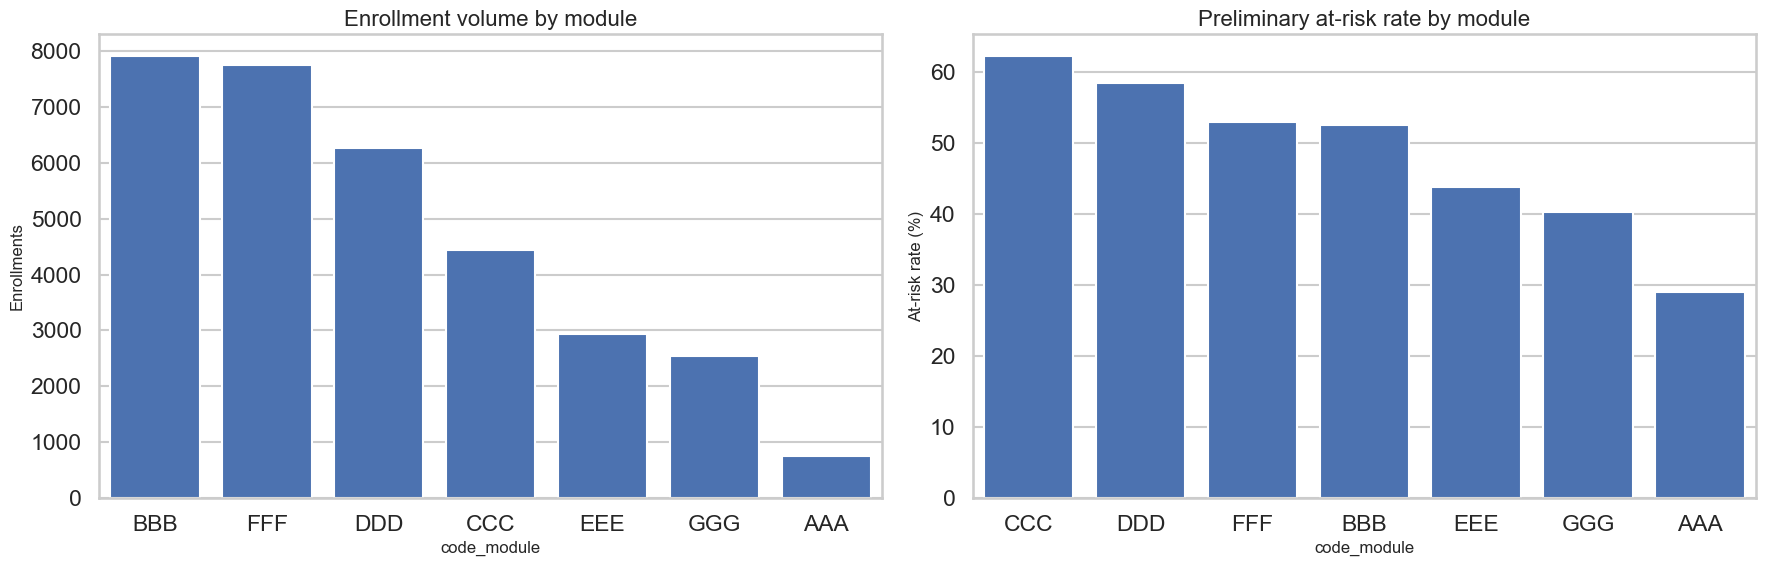

In [12]:
module_counts = eda_base["code_module"].value_counts().rename_axis("code_module").reset_index(name="enrollments")
module_risk = (
    eda_base.groupby("code_module", observed=True)["at_risk_eda"]
    .mean()
    .mul(100)
    .rename("at_risk_rate")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=module_counts, x="code_module", y="enrollments", ax=axes[0])
axes[0].set_title("Enrollment volume by module")
axes[0].set_xlabel("code_module")
axes[0].set_ylabel("Enrollments")

sns.barplot(data=module_risk.sort_values("at_risk_rate", ascending=False), x="code_module", y="at_risk_rate", ax=axes[1])
axes[1].set_title("Preliminary at-risk rate by module")
axes[1].set_xlabel("code_module")
axes[1].set_ylabel("At-risk rate (%)")

plt.tight_layout()

final_result,Distinction,Pass,Fail,Withdrawn,n
code_module,,,,,
AAA,5.882,65.107,12.166,16.845,748
BBB,8.560,38.905,22.342,30.193,7909
CCC,11.231,26.613,17.614,44.542,4434
DDD,6.107,35.507,22.513,35.874,6272
EEE,12.134,44.104,19.155,24.608,2934
FFF,8.632,38.366,22.043,30.959,7762
GGG,15.627,44.120,28.729,11.523,2534


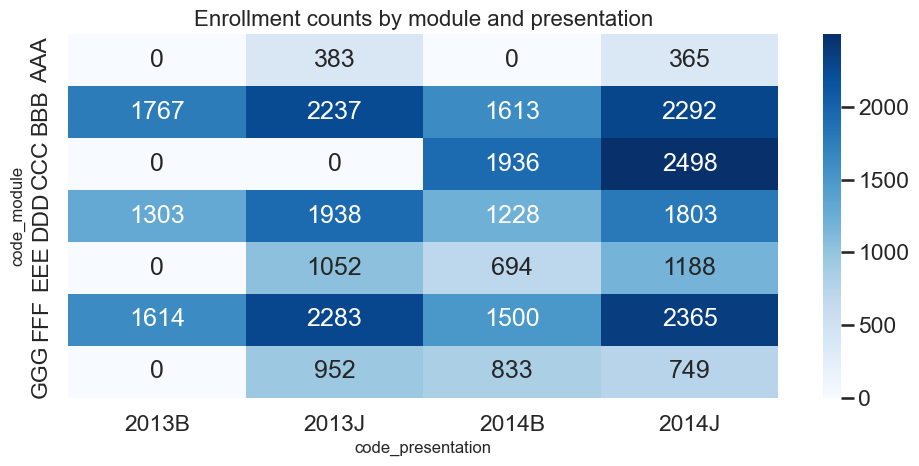

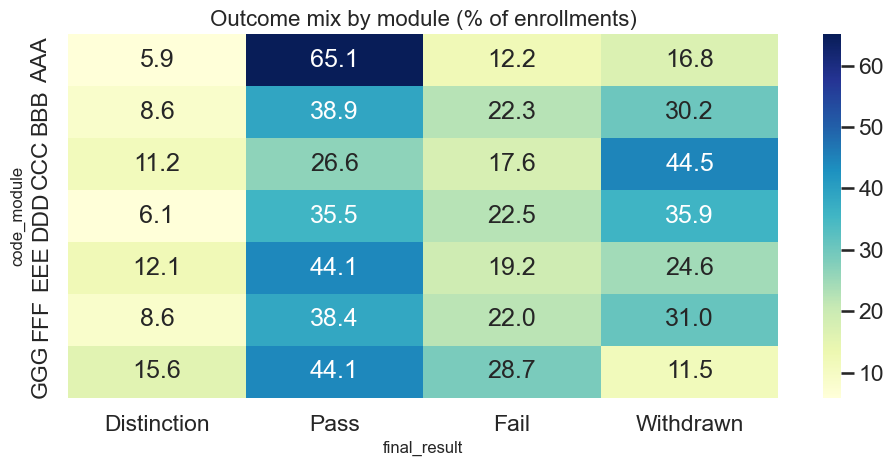

In [13]:
presentation_mix = (
    eda_base.groupby(["code_module", "code_presentation"], observed=True)
    .size()
    .unstack(fill_value=0)
)
plt.figure(figsize=(10, 5))
sns.heatmap(presentation_mix, annot=True, fmt=".0f", cmap="Blues")
plt.title("Enrollment counts by module and presentation")
plt.xlabel("code_presentation")
plt.ylabel("code_module")
plt.tight_layout()

module_outcome_mix = plot_outcome_mix(
    eda_base,
    group_col="code_module",
    min_count=100,
    normalize=True,
    figsize=(10, 5),
    title="Outcome mix by module (% of enrollments)",
)
display(module_outcome_mix)

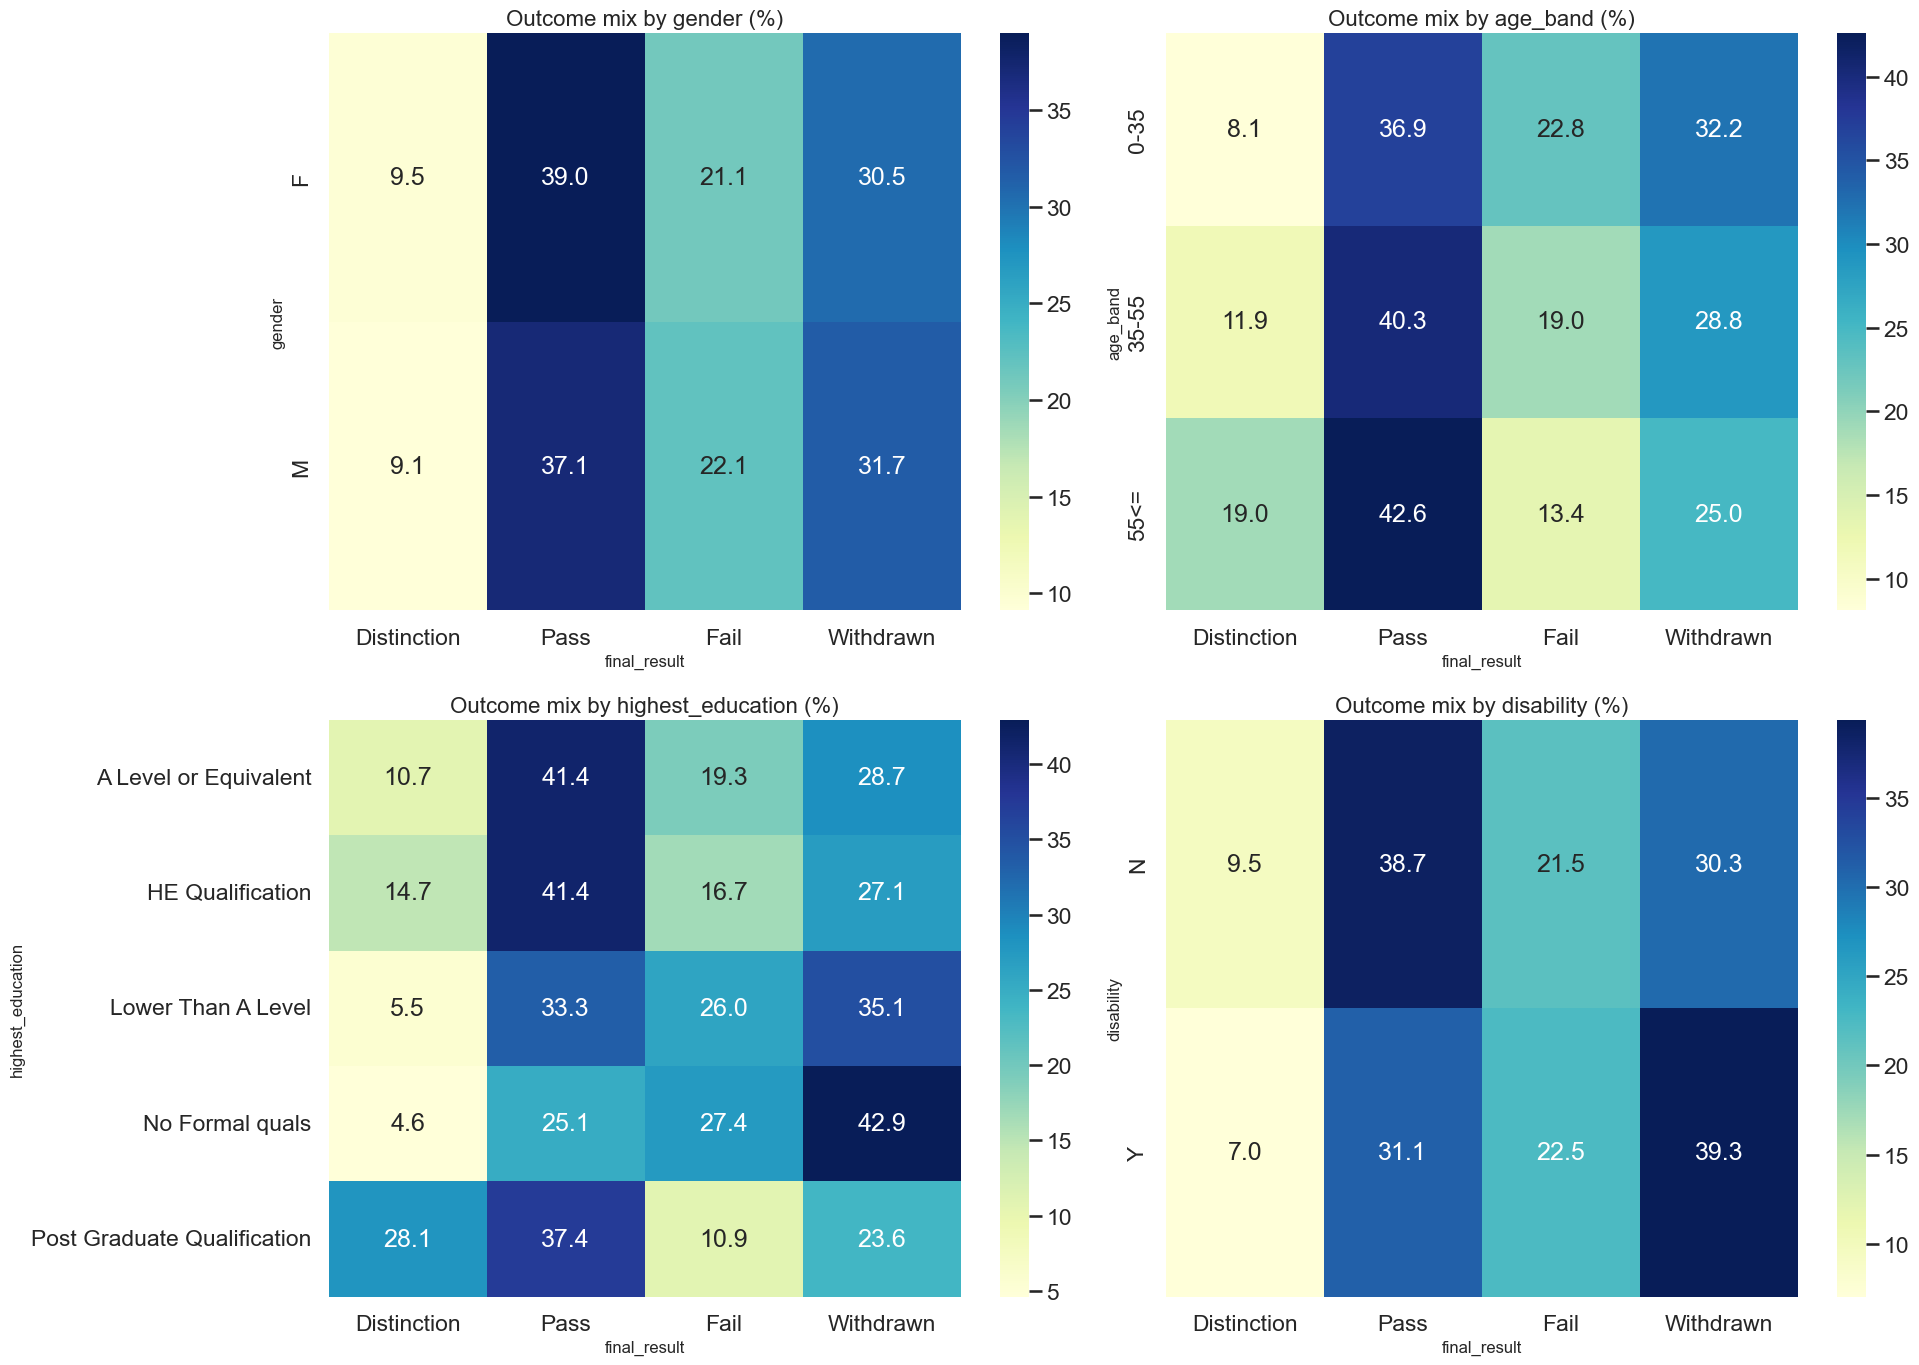

In [14]:
profile_outcome_vars = [
    ("gender", None),
    ("age_band", ["0-35", "35-55", "55<="]),
    ("highest_education", None),
    ("disability", ["N", "Y"]),
]

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for ax, (column, order) in zip(axes, profile_outcome_vars):
    mix = outcome_mix_table(eda_base, column, min_count=50, normalize=True, order=order)
    sns.heatmap(mix[OUTCOME_ORDER], annot=True, fmt=".1f", cmap="YlGnBu", ax=ax)
    ax.set_title(f"Outcome mix by {column} (%)")
    ax.set_xlabel("final_result")
    ax.set_ylabel(column)

plt.tight_layout()

final_result,Distinction,Pass,Fail,Withdrawn,n
num_of_prev_attempts,,,,,
0,10.052,39.225,20.165,30.558,28421
1,4.335,30.221,30.585,34.859,3299
2,3.259,25.185,34.963,36.593,675
3,0.704,21.831,40.141,37.324,142


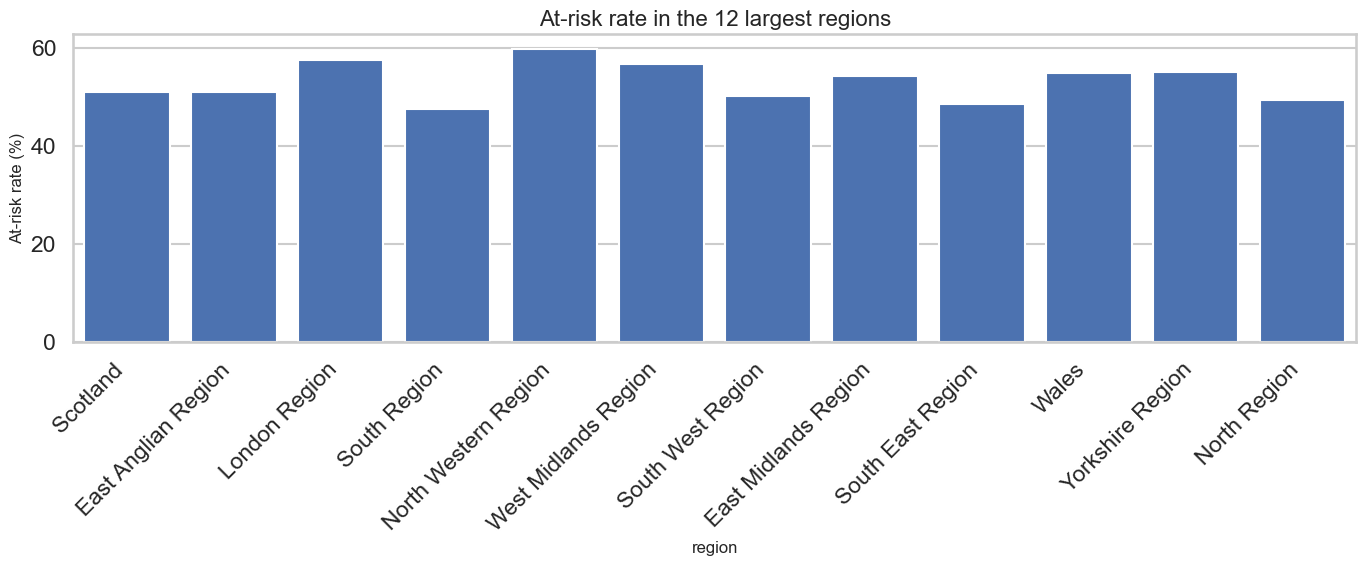

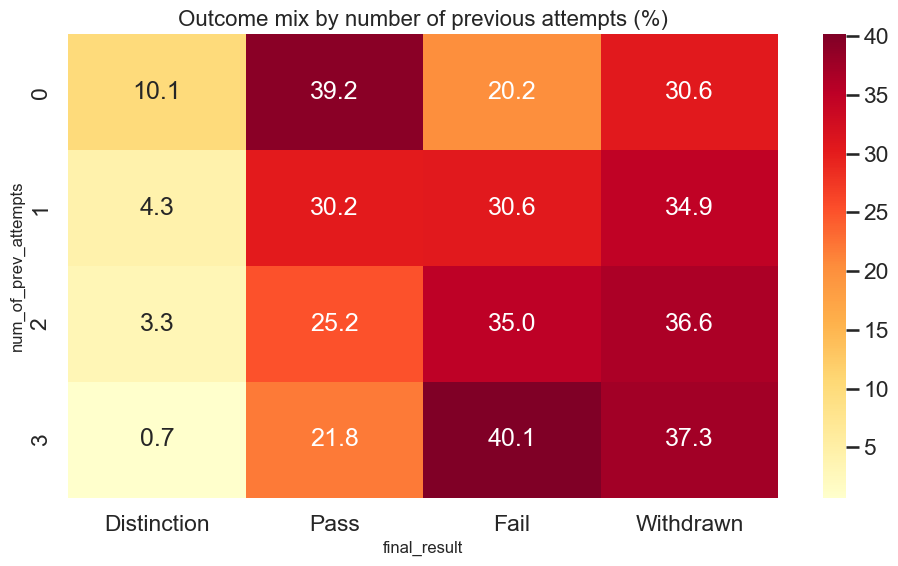

In [15]:
region_summary = (
    eda_base.groupby("region", observed=True)
    .agg(
        enrollments=("id_student", "size"),
        at_risk_rate=("at_risk_eda", "mean"),
    )
    .assign(at_risk_rate=lambda df: df["at_risk_rate"] * 100)
    .sort_values(["enrollments", "at_risk_rate"], ascending=[False, False])
)

top_regions = region_summary.head(12).reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=top_regions, x="region", y="at_risk_rate")
plt.title("At-risk rate in the 12 largest regions")
plt.xlabel("region")
plt.ylabel("At-risk rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

attempt_mix = outcome_mix_table(eda_base, "num_of_prev_attempts", min_count=50, normalize=True)
display(attempt_mix)

plt.figure(figsize=(10, 6))
sns.heatmap(attempt_mix[OUTCOME_ORDER], annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Outcome mix by number of previous attempts (%)")
plt.xlabel("final_result")
plt.ylabel("num_of_prev_attempts")
plt.tight_layout()

final_result,Distinction,Pass,Fail,Withdrawn,n
studied_credits_band,,,,,
<=60,10.127,41.672,22.851,25.350,"20,568.000"
61-90,9.529,34.152,20.539,35.780,"3,379.000"
91-120,8.200,32.019,19.468,40.313,"6,390.000"
121-180,4.431,28.163,19.475,47.930,"1,715.000"
181-240,3.529,20.235,13.647,62.588,425.000
241-360,3.810,17.143,20.952,58.095,105.000
360+,NaN,NaN,NaN,NaN,NaN


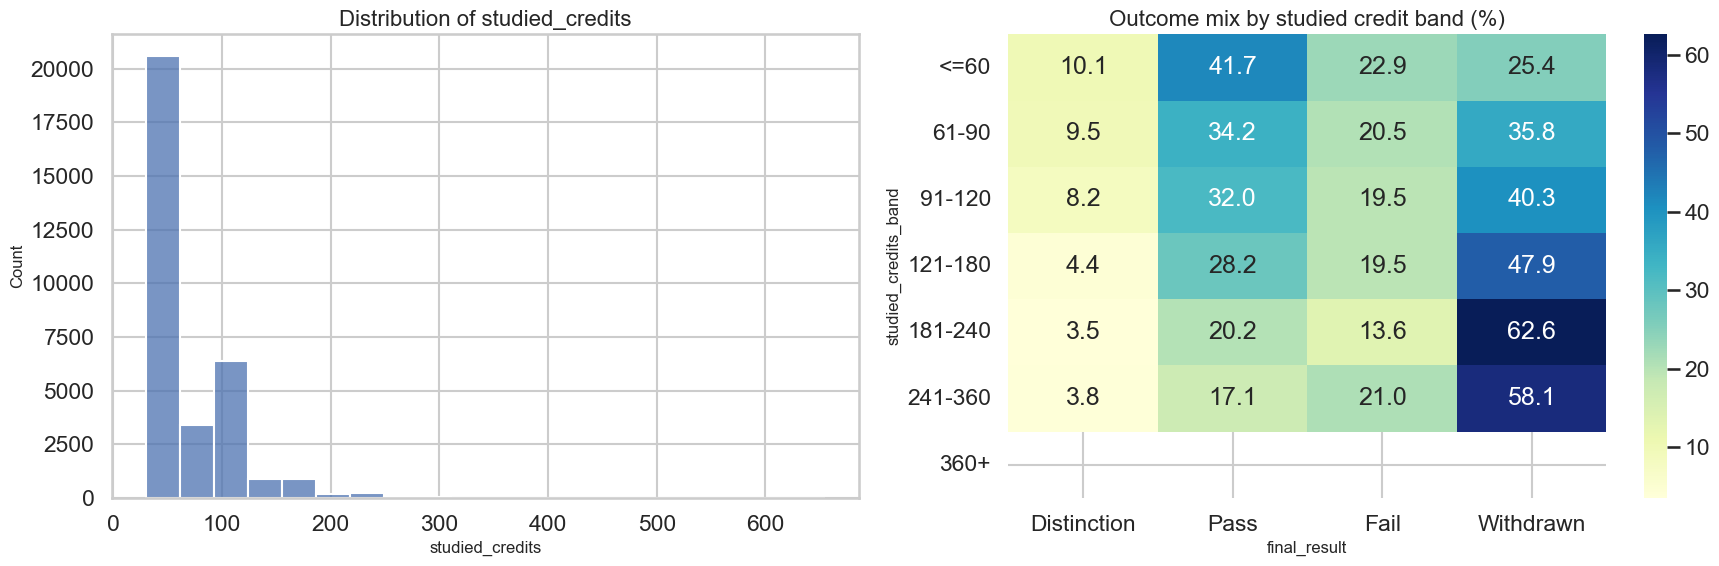

In [16]:
credit_mix = outcome_mix_table(
    eda_base.dropna(subset=["studied_credits_band"]),
    "studied_credits_band",
    min_count=50,
    normalize=True,
    order=studied_credit_labels,
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(data=eda_base, x="studied_credits", bins=20, ax=axes[0])
axes[0].set_title("Distribution of studied_credits")
axes[0].set_xlabel("studied_credits")
axes[0].set_ylabel("Count")

sns.heatmap(credit_mix[OUTCOME_ORDER], annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Outcome mix by studied credit band (%)")
axes[1].set_xlabel("final_result")
axes[1].set_ylabel("studied_credits_band")

plt.tight_layout()
display(credit_mix)

In [17]:
module_risk_ranked = (
    eda_base.groupby("code_module", observed=True)["at_risk_eda"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

attempt_risk = (
    eda_base.groupby("num_of_prev_attempts", observed=True)
    .agg(enrollments=("id_student", "size"), at_risk_rate=("at_risk_eda", "mean"))
    .assign(at_risk_rate=lambda df: df["at_risk_rate"] * 100)
    .query("enrollments >= 50")
    .sort_values("at_risk_rate", ascending=False)
)

disability_risk = (
    eda_base.groupby("disability", observed=True)["at_risk_eda"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)


**Learner profile interpretation**

- Course context matters immediately: module CCC has the highest preliminary at-risk rate (62.2%), while module AAA has the lowest (29.0%).
- Repeated enrollment is a material warning sign. Among attempt groups with at least 50 enrollments, the highest at-risk rate occurs at `num_of_prev_attempts = 3` (77.5%).
- Demographic effects are not uniform: disability-tagged learners show a higher at-risk rate (61.9%) than non-disability learners (51.8%).
- Age and education patterns suggest that learner maturity and prior academic capital likely interact with self-regulation, persistence, and assessment discipline.
- Heavier study loads are more withdrawal-heavy, which is important for both support targeting and recommendation design.


### 5.1 Outcome distribution and course context

Use `final_result` as the main educational outcome and compare risk across modules and presentations.


,final_result,count,pct
0,Distinction,3024,9.278
1,Pass,12361,37.925
2,Fail,7052,21.637
3,Withdrawn,10156,31.160


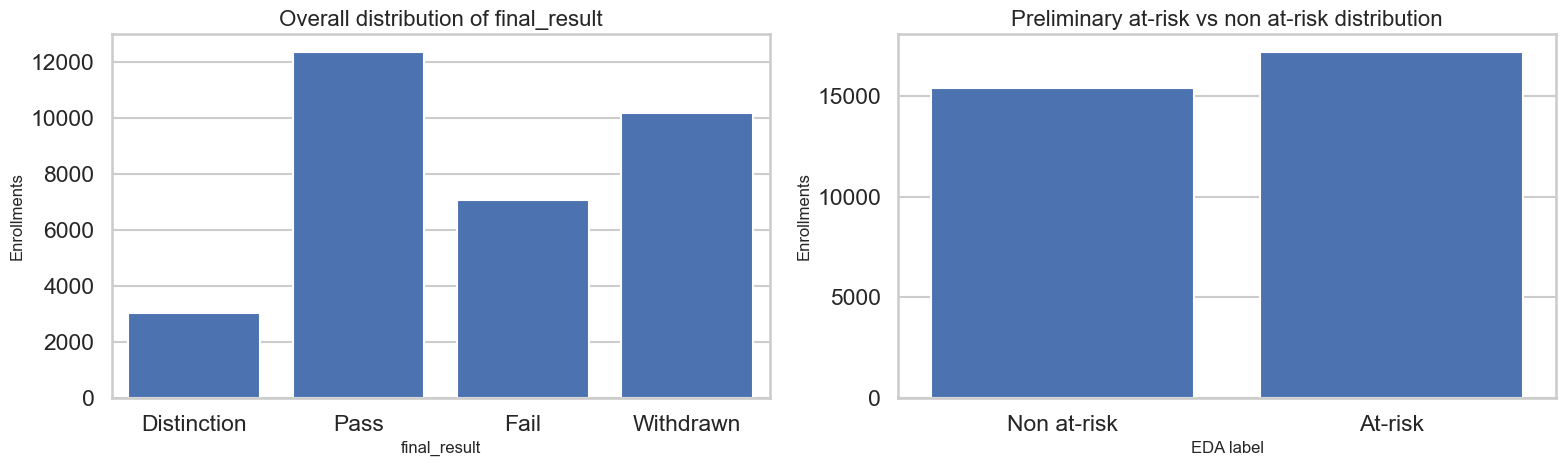

In [18]:
overall_outcome = eda_base["final_result"].value_counts().reindex(OUTCOME_ORDER)
at_risk_summary = eda_base["at_risk_label"].value_counts().reindex(["Non at-risk", "At-risk"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=overall_outcome.index, y=overall_outcome.values, ax=axes[0])
axes[0].set_title("Overall distribution of final_result")
axes[0].set_xlabel("final_result")
axes[0].set_ylabel("Enrollments")

sns.barplot(x=at_risk_summary.index, y=at_risk_summary.values, ax=axes[1])
axes[1].set_title("Preliminary at-risk vs non at-risk distribution")
axes[1].set_xlabel("EDA label")
axes[1].set_ylabel("Enrollments")

plt.tight_layout()

display(
    pd.DataFrame(
        {
            "final_result": overall_outcome.index,
            "count": overall_outcome.values,
            "pct": overall_outcome.values / overall_outcome.sum() * 100,
        }
    )
)

enrollments  at_risk_rate  withdrawn_rate  fail_rate
code_module code_presentation                                                      
CCC         2014B                     1936        65.754          46.384     19.370
DDD         2014B                     1228        60.993          39.902     21.091
            2013B                     1303        60.860          33.154     27.705
CCC         2014J                     2498        59.367          43.114     16.253
DDD         2013J                     1938        57.224          35.139     22.085
FFF         2014B                     1500        56.400          30.800     25.600
DDD         2014J                     1803        56.073          35.885     20.189
BBB         2014B                     1613        54.929          30.378     24.551
            2013B                     1767        54.556          28.580     25.976
FFF         2014J                     2365        52.770          36.152     16.617

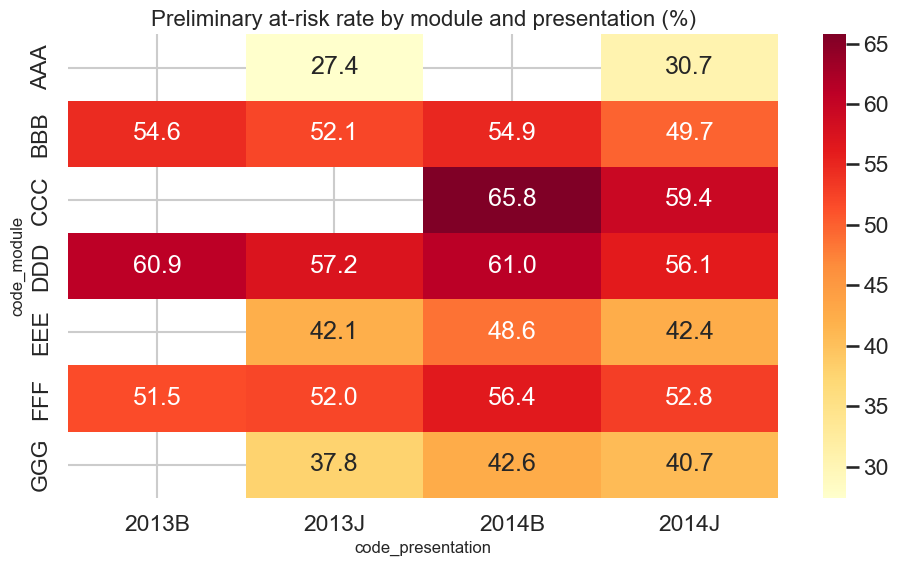

In [19]:
module_presentation_risk = (
    eda_base.groupby(["code_module", "code_presentation"], observed=True)["at_risk_eda"]
    .mean()
    .mul(100)
    .unstack()
    .sort_index()
)

plt.figure(figsize=(10, 6))
sns.heatmap(module_presentation_risk, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Preliminary at-risk rate by module and presentation (%)")
plt.xlabel("code_presentation")
plt.ylabel("code_module")
plt.tight_layout()

course_setting_summary = (
    eda_base.groupby(["code_module", "code_presentation"], observed=True)
    .agg(
        enrollments=("id_student", "size"),
        at_risk_rate=("at_risk_eda", "mean"),
        withdrawn_rate=("final_result", lambda s: s.eq("Withdrawn").mean()),
        fail_rate=("final_result", lambda s: s.eq("Fail").mean()),
    )
    .assign(
        at_risk_rate=lambda df: df["at_risk_rate"] * 100,
        withdrawn_rate=lambda df: df["withdrawn_rate"] * 100,
        fail_rate=lambda df: df["fail_rate"] * 100,
    )
    .sort_values("at_risk_rate", ascending=False)
)

display(course_setting_summary.head(10))

In [20]:
best_setting = course_setting_summary.index[course_setting_summary["at_risk_rate"].argmin()]
worst_setting = course_setting_summary.index[course_setting_summary["at_risk_rate"].argmax()]


**Outcome interpretation**

- The outcome distribution is broad rather than concentrated: 31.2% of enrollments end in `Withdrawn` and 21.6% in `Fail`.
- That makes attrition almost as important as outright academic failure; the project should treat persistence and performance as linked, not separate, problems.
- The highest-risk module-presentation is CCC 2014B (65.8% at-risk), while the lowest-risk setting is AAA 2013J (27.4% at-risk).
- The large spread across course settings justifies including module and presentation context in later segmentation, recommendation, and predictive modeling.


## 6. Engagement behavior

Measure how much learners interact, how concentrated activity is, and whether simple engagement metrics already separate outcomes.


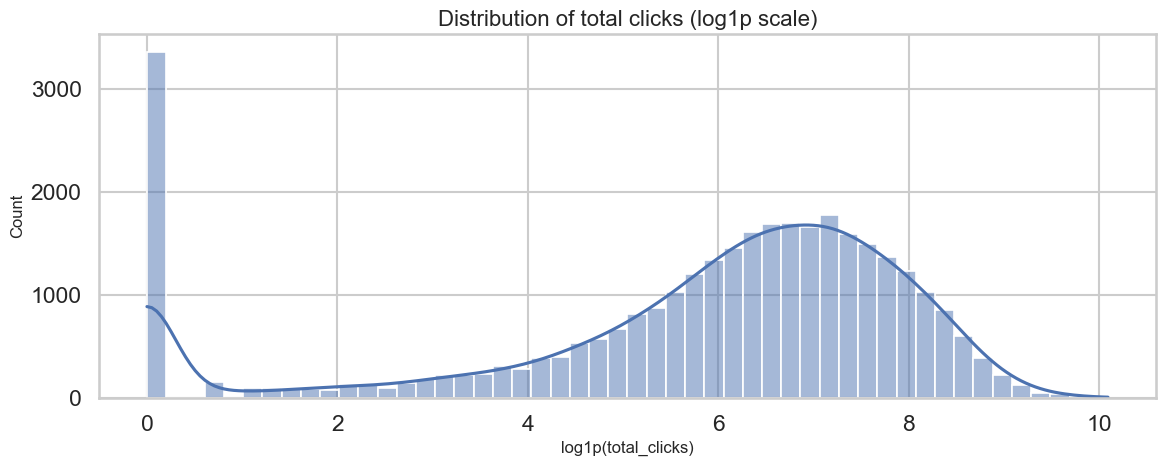

In [21]:
plot_numeric_distribution(
    eda_base["total_clicks"],
    title="Distribution of total clicks (log1p scale)",
    xlabel="total_clicks",
    bins=50,
    log1p=True,
)


**Interpretation note**

- Use the log-transformed view for `total_clicks` when interpreting the chart because the raw click distribution is highly right-skewed.
- Keep the raw scale for business meaning, but use the log scale to compare typical learner behavior more fairly.


,threshold,share_of_all_clicks
0,Top 10% of enrollments,43.074
1,Top 20% of enrollments,63.836


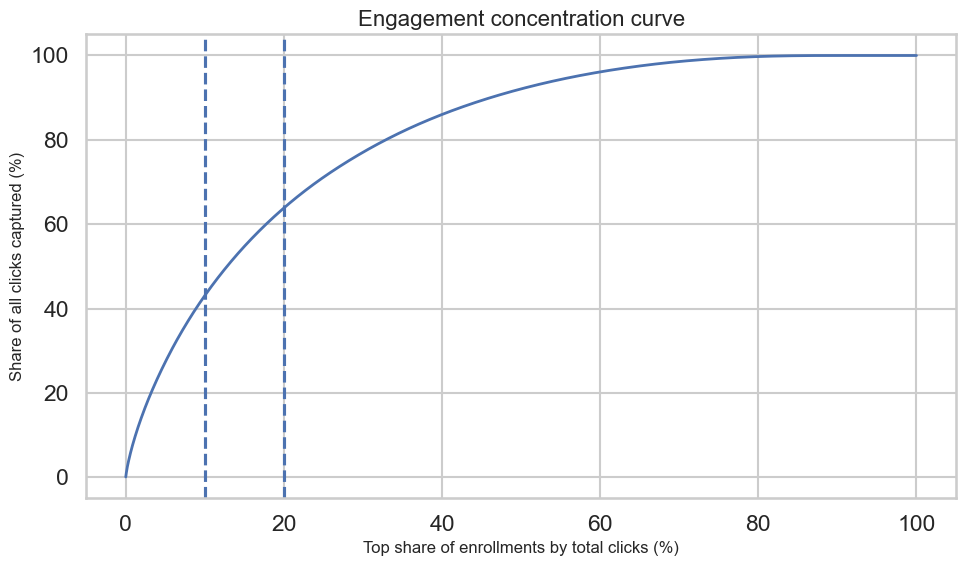

In [22]:
clicks_sorted = eda_base["total_clicks"].sort_values(ascending=False).reset_index(drop=True)
cum_click_share = clicks_sorted.cumsum() / clicks_sorted.sum() * 100
population_share = (np.arange(1, len(clicks_sorted) + 1) / len(clicks_sorted)) * 100

top10_click_share = cum_click_share.iloc[max(int(len(clicks_sorted) * 0.10) - 1, 0)]
top20_click_share = cum_click_share.iloc[max(int(len(clicks_sorted) * 0.20) - 1, 0)]

plt.figure(figsize=(10, 6))
plt.plot(population_share, cum_click_share, linewidth=2)
plt.axvline(10, linestyle="--")
plt.axvline(20, linestyle="--")
plt.title("Engagement concentration curve")
plt.xlabel("Top share of enrollments by total clicks (%)")
plt.ylabel("Share of all clicks captured (%)")
plt.tight_layout()

display(
    pd.DataFrame(
        {
            "threshold": ["Top 10% of enrollments", "Top 20% of enrollments"],
            "share_of_all_clicks": [top10_click_share, top20_click_share],
        }
    )
)

,enrollments,median_total_clicks,median_total_active_days,median_clicks_per_active_day,median_clicks_14d,median_clicks_30d,early_active_14d_rate,pre_start_engagement_rate,median_last_activity,median_recency_from_end
final_result,,,,,,,,,,
Distinction,3024,"1,896.000",103.000,19.358,156.000,332.500,96.991,89.649,241.000,8.000
Pass,12361,"1,343.000",78.000,17.824,104.000,238.000,95.065,84.661,240.000,12.000
Fail,7052,317.000,22.000,14.026,40.000,110.000,83.310,69.073,148.000,116.000
Withdrawn,10156,89.000,7.000,10.153,12.000,38.000,59.265,56.735,51.000,233.000


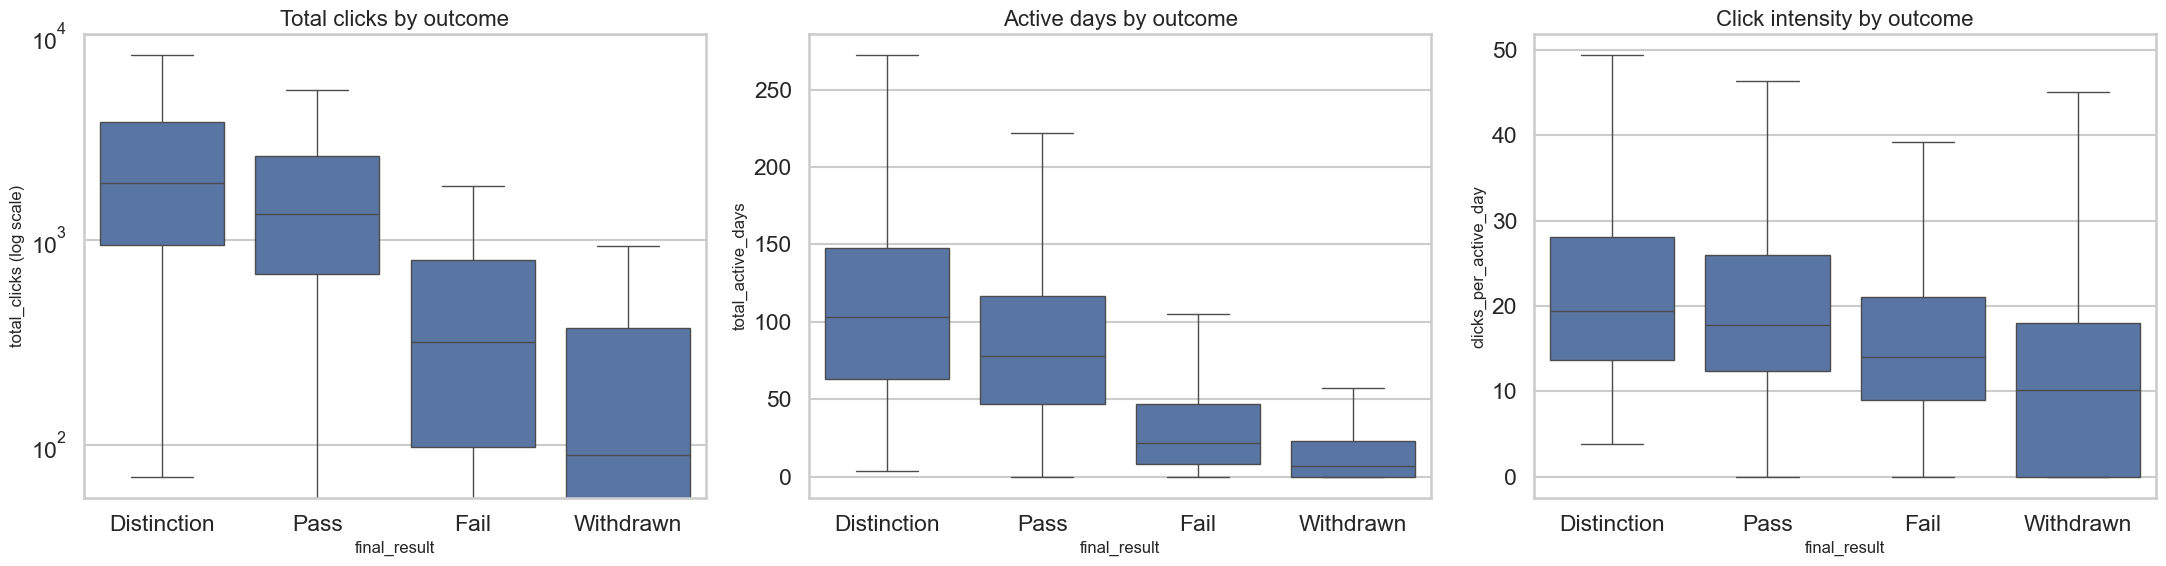

In [23]:
engagement_vars = ["total_clicks", "total_active_days", "clicks_per_active_day"]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.boxplot(data=eda_base, x="final_result", y="total_clicks", order=OUTCOME_ORDER, ax=axes[0], showfliers=False)
axes[0].set_yscale("log")
axes[0].set_title("Total clicks by outcome")
axes[0].set_xlabel("final_result")
axes[0].set_ylabel("total_clicks (log scale)")

sns.boxplot(data=eda_base, x="final_result", y="total_active_days", order=OUTCOME_ORDER, ax=axes[1], showfliers=False)
axes[1].set_title("Active days by outcome")
axes[1].set_xlabel("final_result")
axes[1].set_ylabel("total_active_days")

sns.boxplot(data=eda_base, x="final_result", y="clicks_per_active_day", order=OUTCOME_ORDER, ax=axes[2], showfliers=False)
axes[2].set_title("Click intensity by outcome")
axes[2].set_xlabel("final_result")
axes[2].set_ylabel("clicks_per_active_day")

plt.tight_layout()

engagement_summary = (
    eda_base.groupby("final_result", observed=True)
    .agg(
        enrollments=("id_student", "size"),
        median_total_clicks=("total_clicks", "median"),
        median_total_active_days=("total_active_days", "median"),
        median_clicks_per_active_day=("clicks_per_active_day", "median"),
        median_clicks_14d=("clicks_14d", "median"),
        median_clicks_30d=("clicks_30d", "median"),
        early_active_14d_rate=("early_active_flag_14d", "mean"),
        pre_start_engagement_rate=("engaged_pre_start", "mean"),
        median_last_activity=("last_activity_date", "median"),
        median_recency_from_end=("engagement_recency_from_end", "median"),
    )
    .assign(
        early_active_14d_rate=lambda df: df["early_active_14d_rate"] * 100,
        pre_start_engagement_rate=lambda df: df["pre_start_engagement_rate"] * 100,
    )
)

display(engagement_summary)

,code_module,code_presentation,median_total_clicks,median_active_days,vle_activity_rate
15,FFF,2013B,"2,150.500",69.500,93.556
16,FFF,2013J,"1,633.000",59.000,91.897
18,FFF,2014J,"1,592.000",55.000,89.683
17,FFF,2014B,"1,442.000",51.000,90.867
0,AAA,2013J,"1,216.000",78.000,98.695
12,EEE,2013J,"1,128.500",57.000,91.635
14,EEE,2014J,"1,117.500",58.000,92.340
1,AAA,2014J,"1,067.000",71.000,97.808
13,EEE,2014B,910.500,50.000,89.914
8,DDD,2013B,754.000,56.000,93.170


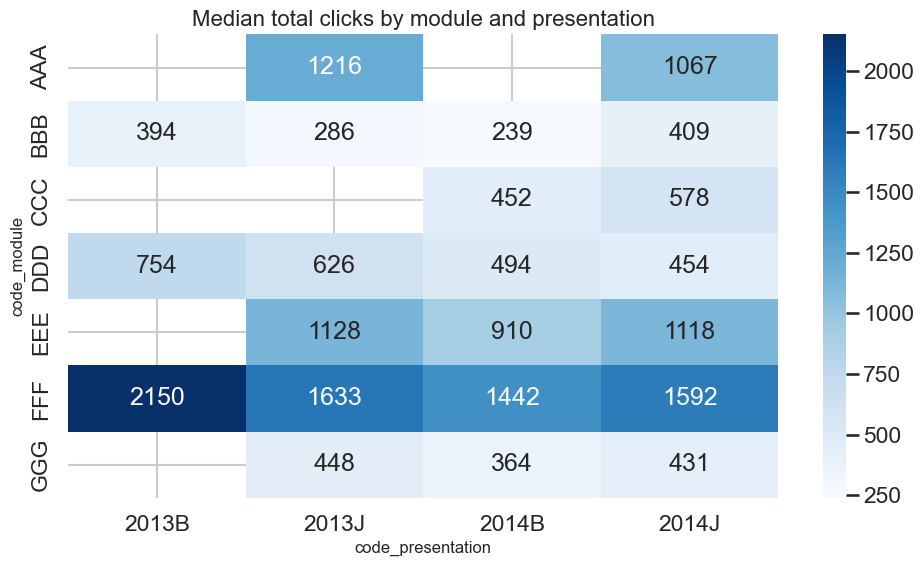

In [24]:
module_engagement = (
    eda_base.groupby(["code_module", "code_presentation"], observed=True)
    .agg(
        median_total_clicks=("total_clicks", "median"),
        median_active_days=("total_active_days", "median"),
        vle_activity_rate=("has_vle_activity", "mean"),
    )
    .assign(vle_activity_rate=lambda df: df["vle_activity_rate"] * 100)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    module_engagement.pivot(index="code_module", columns="code_presentation", values="median_total_clicks"),
    annot=True,
    fmt=".0f",
    cmap="Blues",
)
plt.title("Median total clicks by module and presentation")
plt.xlabel("code_presentation")
plt.ylabel("code_module")
plt.tight_layout()

display(module_engagement.sort_values("median_total_clicks", ascending=False).head(10))

In [25]:
withdrawn_zero_click_rate = (
    eda_base.loc[eda_base["final_result"].eq("Withdrawn"), "total_clicks"].eq(0).mean() * 100
)


**Engagement interpretation**

- Engagement is extremely skewed: the top 10% of enrollments account for 43.1% of all clicks, and the top 20% account for 63.8%.
- Outcome separation is already visible in simple usage measures. Median total clicks range from 89 for `Withdrawn` to 1,896 for `Distinction`.
- Early engagement matters: 97.0% of `Distinction` enrollments are active in the first 14 days, compared with only 59.3% of `Withdrawn` enrollments.
- `Withdrawn` learners often disengage almost completely: 29.4% record zero clicks at all.
- These patterns directly motivate engagement-based features such as active days, early clicks, pre-start engagement, and recency-to-course-end.


### 6.1 Timing across the course

Move from total activity volume to activity timing, because early divergence matters for intervention.


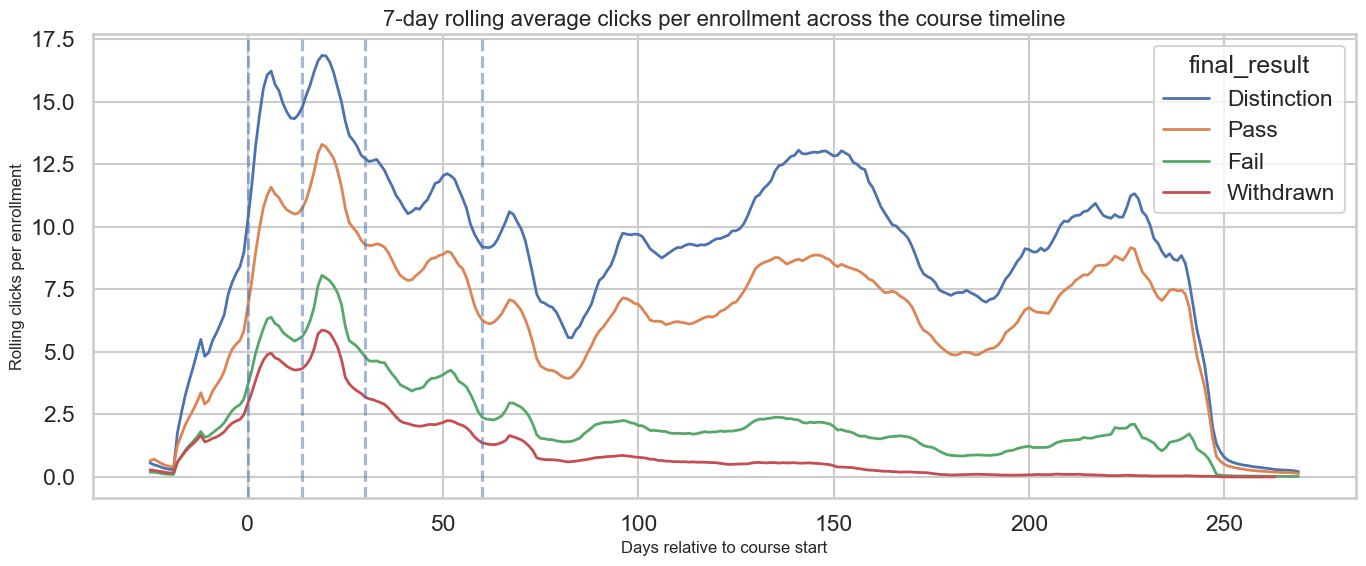

In [26]:
group_sizes = eda_base["final_result"].value_counts().rename("group_size").reset_index().rename(columns={"index": "final_result"})

daily_norm = daily_clicks_by_result.merge(group_sizes, on="final_result", how="left")
daily_norm["avg_clicks_per_enrollment"] = daily_norm["total_clicks"] / daily_norm["group_size"]
daily_norm = daily_norm.sort_values(["final_result", "date"])
daily_norm["rolling_7d_clicks_per_enrollment"] = (
    daily_norm.groupby("final_result", observed=True)["avg_clicks_per_enrollment"]
    .transform(lambda s: s.rolling(7, min_periods=1).mean())
)

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=daily_norm,
    x="date",
    y="rolling_7d_clicks_per_enrollment",
    hue="final_result",
    hue_order=OUTCOME_ORDER,
    linewidth=2,
)
for vline in [0, 14, 30, 60]:
    plt.axvline(vline, linestyle="--", alpha=0.5)
plt.title("7-day rolling average clicks per enrollment across the course timeline")
plt.xlabel("Days relative to course start")
plt.ylabel("Rolling clicks per enrollment")
plt.tight_layout()

,final_result,date,rolling_7d_clicks_per_enrollment
44,Distinction,19,16.854
634,Fail,19,8.060
339,Pass,19,13.297
929,Withdrawn,19,5.871


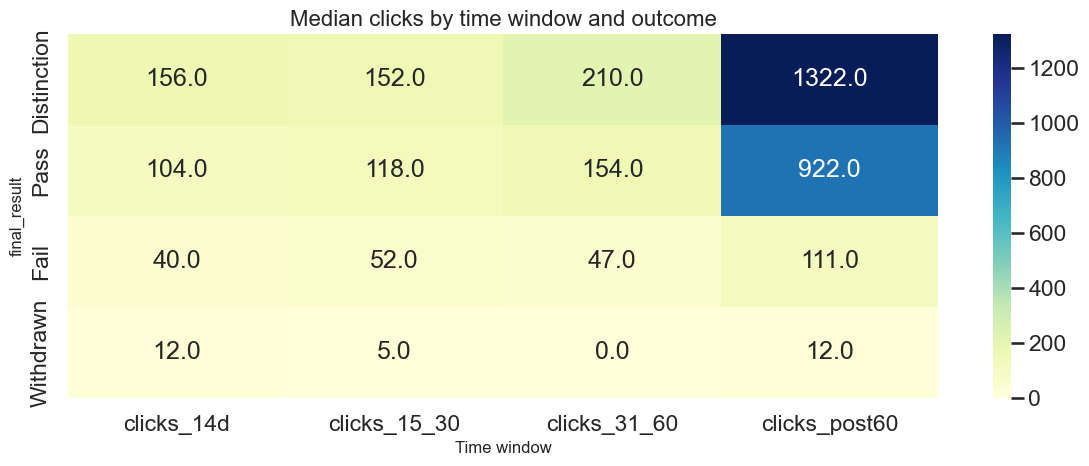

In [27]:
window_summary = (
    eda_base.groupby("final_result", observed=True)[["clicks_14d", "clicks_15_30", "clicks_31_60", "clicks_post60"]]
    .median()
    .reindex(OUTCOME_ORDER)
)

plt.figure(figsize=(12, 5))
sns.heatmap(window_summary, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Median clicks by time window and outcome")
plt.xlabel("Time window")
plt.ylabel("final_result")
plt.tight_layout()

peak_points = (
    daily_norm.sort_values("rolling_7d_clicks_per_enrollment", ascending=False)
    .groupby("final_result", observed=True)
    .head(1)
    .sort_values("final_result")
)

display(peak_points[["final_result", "date", "rolling_7d_clicks_per_enrollment"]])

In [28]:
peak_lookup = peak_points.set_index("final_result")["date"].to_dict()


**Time-based interpretation**

- All outcome groups show an early-course engagement rise, but the magnitude differs sharply. The 7-day rolling peak for `Distinction` occurs around day 19, compared with much lower intensity for `Fail` and `Withdrawn`.
- The first two weeks already separate groups: median `clicks_14d` are 156 for `Distinction`, 104 for `Pass`, 40 for `Fail`, and only 12 for `Withdrawn`.
- Withdrawn learners show a rapid collapse after the start of the presentation, while successful learners sustain activity well beyond the first month.
- This supports feature windows at 14, 30, and 60 days for later early-warning models and recommendation triggers.


### 6.2 Early-warning view: first 4 weeks

Focus on the first month of activity and submissions to support the at-risk branch.


,final_result,unique_submitters,early_submissions,mean_score,median_score,early_late_rate,enrollments,submitter_rate
0,Distinction,2211,2884,86.538,90.000,20.180,3024,73.115
1,Pass,9432,11473,76.781,80.000,17.023,12361,76.305
2,Fail,4284,4911,67.735,70.000,25.596,7052,60.749
3,Withdrawn,3747,4289,64.985,70.000,35.486,10156,36.894


final_result,Distinction,Pass,Fail,Withdrawn
week_label,,,,
Week 1,125.164,89.620,48.872,38.145
Week 2,103.615,75.251,39.341,30.335
Week 3,116.172,90.881,54.917,40.239
Week 4,92.547,68.444,36.480,24.088


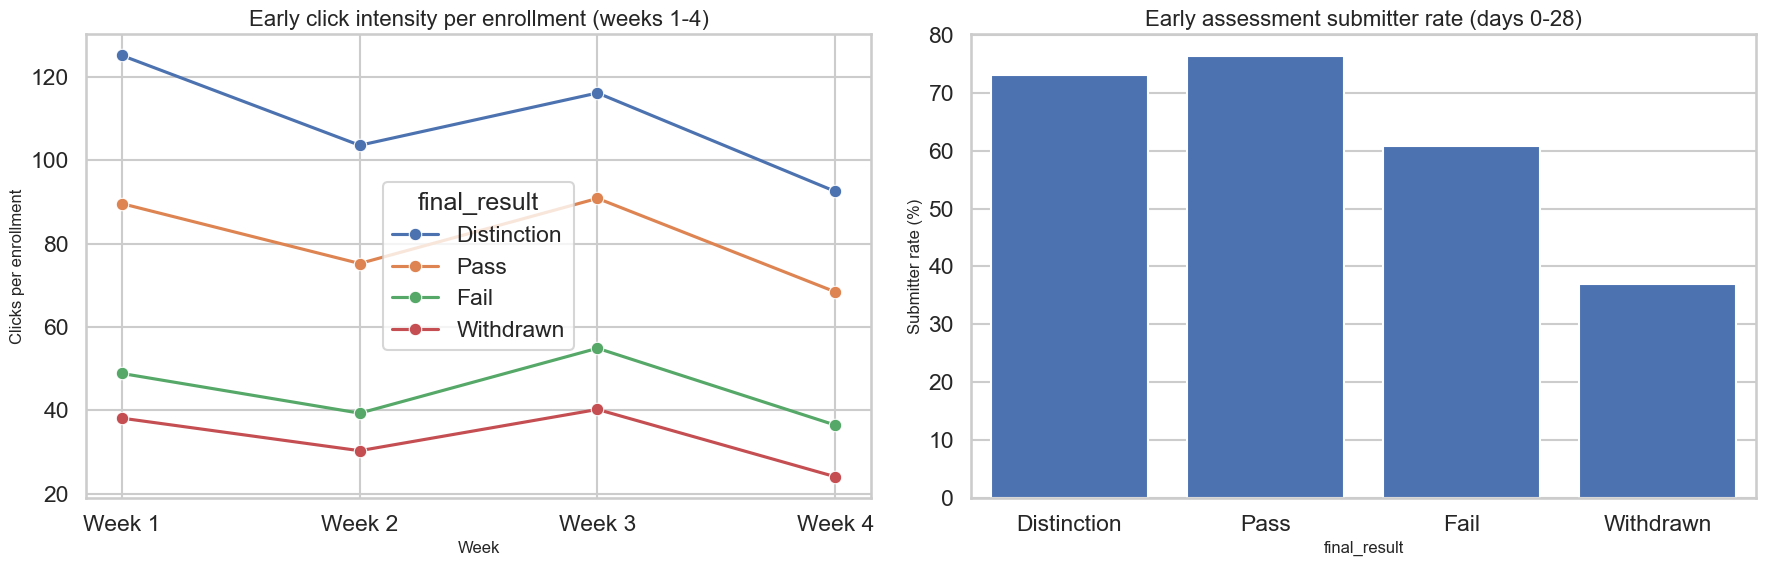

In [29]:

early_clicks = daily_clicks_by_result.loc[daily_clicks_by_result["date"].between(0, 28)].copy()
group_sizes_early = (
    eda_base["final_result"]
    .value_counts()
    .rename_axis("final_result")
    .reset_index(name="enrollments")
)

early_clicks = early_clicks.merge(group_sizes_early, on="final_result", how="left")
early_clicks["week_label"] = pd.cut(
    early_clicks["date"],
    bins=[-1, 7, 14, 21, 28],
    labels=["Week 1", "Week 2", "Week 3", "Week 4"],
)
early_clicks["clicks_per_enrollment"] = early_clicks["total_clicks"] / early_clicks["enrollments"]

early_week_summary = (
    early_clicks.groupby(["week_label", "final_result"], observed=True)["clicks_per_enrollment"]
    .sum()
    .reset_index()
)

early_click_matrix = (
    early_week_summary.pivot(index="week_label", columns="final_result", values="clicks_per_enrollment")
    .reindex(index=["Week 1", "Week 2", "Week 3", "Week 4"], columns=OUTCOME_ORDER)
)

early_assessment = assessment_perf_corrected.loc[
    assessment_perf_corrected["date_submitted"].between(0, 28)
].copy()

if early_assessment.empty:
    early_assessment_summary = pd.DataFrame()
else:
    early_assessment_summary = (
        early_assessment.groupby("final_result", observed=True)
        .agg(
            unique_submitters=("id_student", "nunique"),
            early_submissions=("id_assessment", "size"),
            mean_score=("score", "mean"),
            median_score=("score", "median"),
            early_late_rate=("is_late", "mean"),
        )
        .reset_index()
        .merge(group_sizes_early, on="final_result", how="left")
        .assign(
            submitter_rate=lambda df: df["unique_submitters"] / df["enrollments"] * 100,
            early_late_rate=lambda df: df["early_late_rate"] * 100,
        )
    )
    early_assessment_summary["final_result"] = pd.Categorical(
        early_assessment_summary["final_result"],
        categories=OUTCOME_ORDER,
        ordered=True,
    )
    early_assessment_summary = early_assessment_summary.sort_values("final_result")

    display(early_assessment_summary)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    sns.lineplot(
        data=early_week_summary,
        x="week_label",
        y="clicks_per_enrollment",
        hue="final_result",
        hue_order=OUTCOME_ORDER,
        marker="o",
        ax=axes[0],
    )
    axes[0].set_title("Early click intensity per enrollment (weeks 1-4)")
    axes[0].set_xlabel("Week")
    axes[0].set_ylabel("Clicks per enrollment")

    sns.barplot(
        data=early_assessment_summary,
        x="final_result",
        y="submitter_rate",
        order=OUTCOME_ORDER,
        ax=axes[1],
    )
    axes[1].set_title("Early assessment submitter rate (days 0-28)")
    axes[1].set_xlabel("final_result")
    axes[1].set_ylabel("Submitter rate (%)")

    plt.tight_layout()

    display(early_click_matrix)

    week1_gap = early_click_matrix.loc["Week 1", "Distinction"] - early_click_matrix.loc["Week 1", "Withdrawn"]
    week4_gap = early_click_matrix.loc["Week 4", "Distinction"] - early_click_matrix.loc["Week 4", "Withdrawn"]

    submitter_rate_dist = early_assessment_summary.loc[
        early_assessment_summary["final_result"].eq("Distinction"), "submitter_rate"
    ].iloc[0]
    submitter_rate_with = early_assessment_summary.loc[
        early_assessment_summary["final_result"].eq("Withdrawn"), "submitter_rate"
    ].iloc[0]


**Early-warning interpretation**

- The first four weeks already provide a usable early-warning window for the at-risk branch.
- Week-level click intensity and early assessment participation should be kept as a separate feature family for recall-oriented modeling.
- This section is meant to feed the at-risk notebook, so the emphasis should stay on signals that appear early enough for intervention.


## 7. VLE and content usage

Shift from quantity of clicks to composition of clicks so the project can later support learning-material recommendations.


,activity_type,total_clicks,share_pct
0,oucontent,"11,206,803.000",28.296
1,forumng,"7,973,390.000",20.132
2,quiz,"6,981,240.000",17.627
3,homepage,"6,949,064.000",17.546
4,subpage,"3,411,582.000",8.614
5,resource,"1,110,132.000",2.803
6,ouwiki,"894,512.000",2.259
7,url,"566,702.000",1.431
8,oucollaborate,"108,974.000",0.275
9,glossary,"87,962.000",0.222


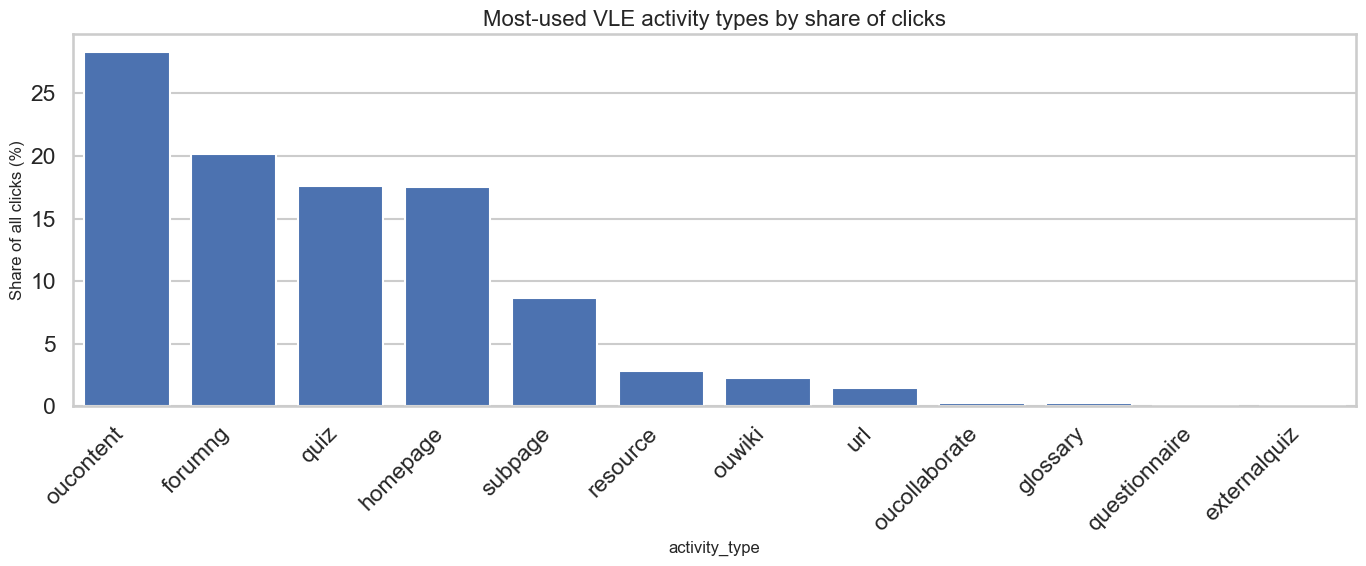

In [30]:
overall_activity = (
    activity_clicks_by_result.groupby("activity_type", observed=True)["total_clicks"]
    .sum()
    .sort_values(ascending=False)
    .rename("total_clicks")
    .reset_index()
)
overall_activity["share_pct"] = overall_activity["total_clicks"] / overall_activity["total_clicks"].sum() * 100

plt.figure(figsize=(14, 6))
sns.barplot(data=overall_activity.head(12), x="activity_type", y="share_pct")
plt.title("Most-used VLE activity types by share of clicks")
plt.xlabel("activity_type")
plt.ylabel("Share of all clicks (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

display(overall_activity.head(12))

,activity_type,risk_gap_pct_points
0,subpage,2.623
1,homepage,1.534
2,resource,1.221
3,url,0.275
4,page,0.101
5,externalquiz,0.060
6,ouelluminate,0.047
7,htmlactivity,0.025
8,sharedsubpage,0.001
9,repeatactivity,0.000


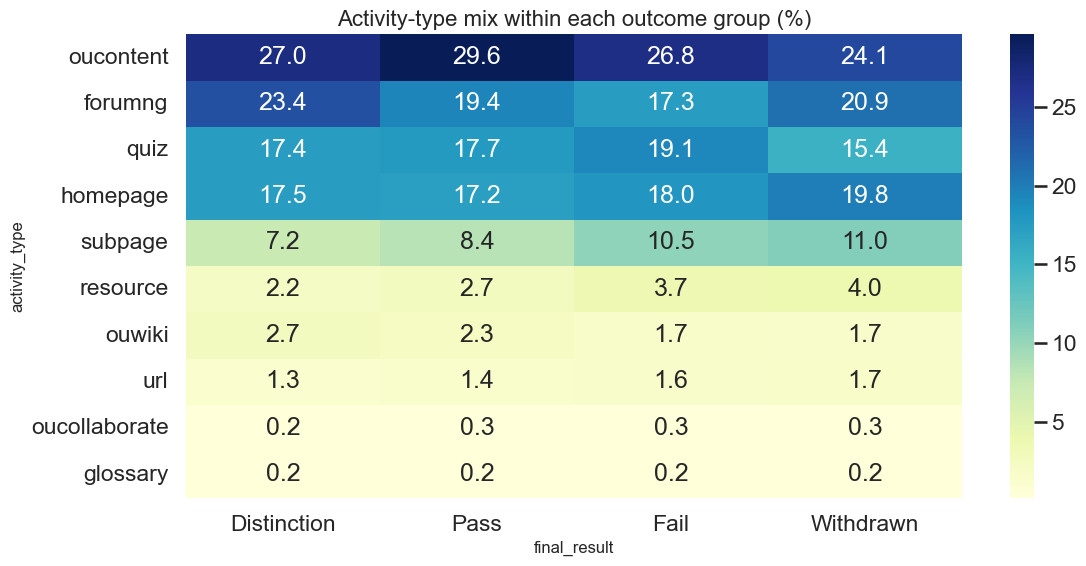

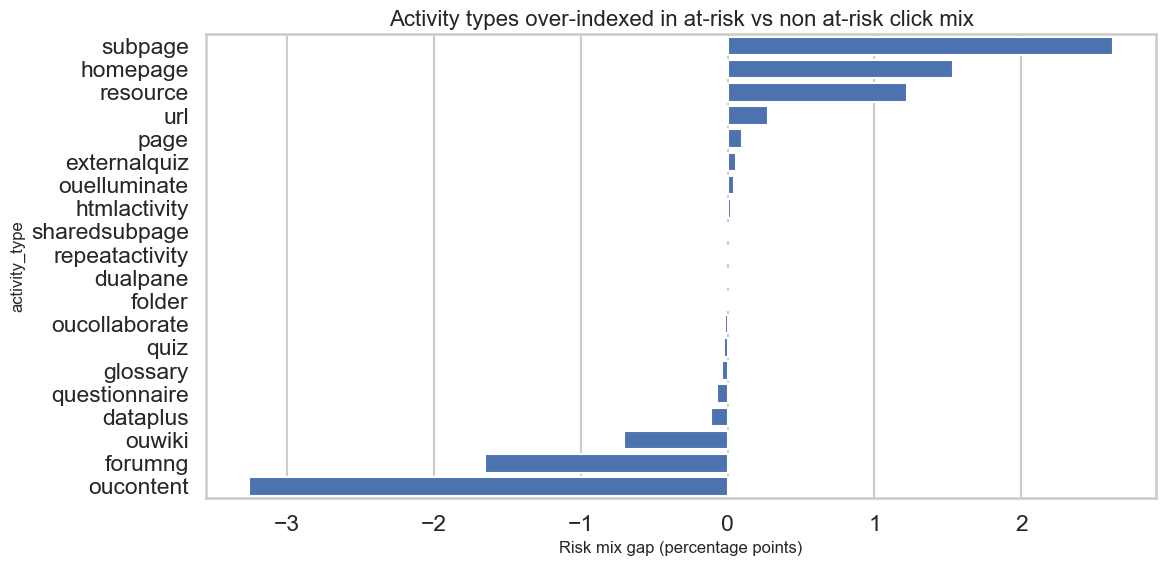

In [31]:
activity_mix = (
    activity_clicks_by_result.pivot(index="activity_type", columns="final_result", values="total_clicks")
    .fillna(0)
    .reindex(columns=OUTCOME_ORDER, fill_value=0)
)
activity_mix_pct = activity_mix.div(activity_mix.sum(axis=0), axis=1) * 100
top_activity_types = overall_activity["activity_type"].head(10).tolist()

plt.figure(figsize=(12, 6))
sns.heatmap(activity_mix_pct.loc[top_activity_types, OUTCOME_ORDER], annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Activity-type mix within each outcome group (%)")
plt.xlabel("final_result")
plt.ylabel("activity_type")
plt.tight_layout()

risk_clicks = activity_mix[["Fail", "Withdrawn"]].sum(axis=1)
nonrisk_clicks = activity_mix[["Distinction", "Pass"]].sum(axis=1)
risk_share = risk_clicks / risk_clicks.sum() * 100
nonrisk_share = nonrisk_clicks / nonrisk_clicks.sum() * 100
risk_gap = (risk_share - nonrisk_share).sort_values(ascending=False).rename("risk_gap_pct_points")

plt.figure(figsize=(12, 6))
sns.barplot(x=risk_gap.values, y=risk_gap.index)
plt.title("Activity types over-indexed in at-risk vs non at-risk click mix")
plt.xlabel("Risk mix gap (percentage points)")
plt.ylabel("activity_type")
plt.tight_layout()

display(risk_gap.reset_index().rename(columns={"index": "activity_type"}))

In [32]:
protective_type = risk_gap.index[-1]
riskiest_type = risk_gap.index[0]


**VLE usage interpretation**

- The click mix is dominated by a small set of activity types, led by `oucontent` (28.3% of all clicks).
- `subpage` is the most over-represented activity type in the at-risk click mix, while `oucontent` is the most over-represented in the non at-risk mix.
- Successful learners spend relatively more of their click budget in learning-content and discussion-oriented spaces, whereas at-risk learners over-index on lighter-navigation behavior.
- These differences suggest recommendation opportunities around resource sequencing, content depth, and nudges toward higher-value learning activities.


## 8. Assessment behavior

Study score quality, completion behavior, and submission discipline as direct drivers of educational outcomes.


,submissions,avg_score,median_score,avg_submission_delay,late_share
assessment_type,,,,,
TMA,98426,72.436,76.000,-1.176,16.581
CMA,70527,81.027,82.000,-38.335,46.778
Exam,4959,65.573,67.000,132.936,57.915


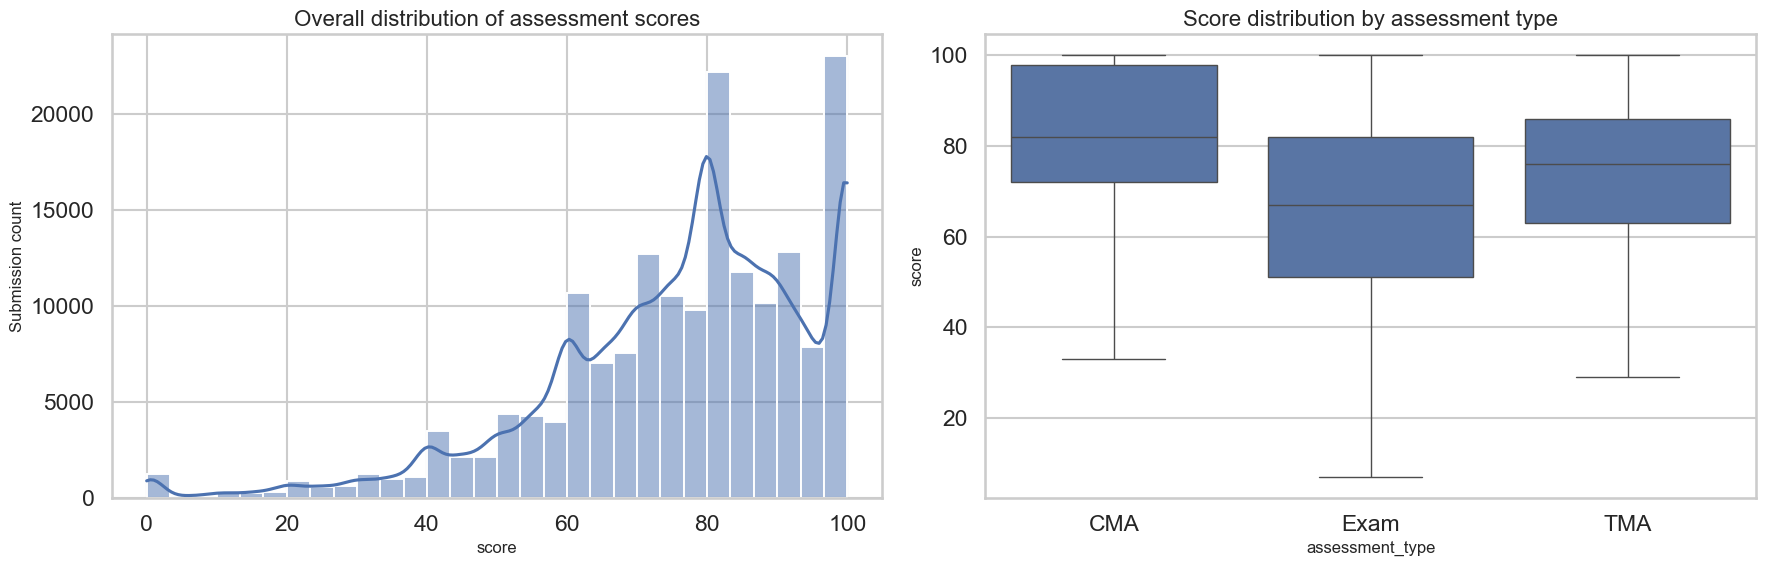

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(data=assessment_perf_corrected, x="score", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Overall distribution of assessment scores")
axes[0].set_xlabel("score")
axes[0].set_ylabel("Submission count")

sns.boxplot(
    data=assessment_perf_corrected,
    x="assessment_type",
    y="score",
    order=sorted(assessment_perf_corrected["assessment_type"].dropna().unique()),
    ax=axes[1],
    showfliers=False,
)
axes[1].set_title("Score distribution by assessment type")
axes[1].set_xlabel("assessment_type")
axes[1].set_ylabel("score")

plt.tight_layout()

assessment_type_summary = (
    assessment_perf_corrected.groupby("assessment_type", observed=True)
    .agg(
        submissions=("id_assessment", "size"),
        avg_score=("score", "mean"),
        median_score=("score", "median"),
        avg_submission_delay=("submission_delay", "mean"),
        late_share=("is_late", "mean"),
    )
    .assign(late_share=lambda df: df["late_share"] * 100)
    .sort_values("submissions", ascending=False)
)

display(assessment_type_summary)

,assessment_submission_rate,median_completion_ratio,mean_completion_ratio,median_avg_score,mean_avg_score,median_weighted_score_sum,median_late_rate_non_exam
final_result,,,,,,,
Distinction,100.000,0.900,0.877,89.417,88.493,89.735,0.083
Pass,99.976,0.900,0.870,77.833,76.153,77.280,0.167
Fail,81.792,0.308,0.403,65.800,64.078,16.600,0.143
Withdrawn,46.209,0.000,0.134,67.667,63.635,0.000,0.000


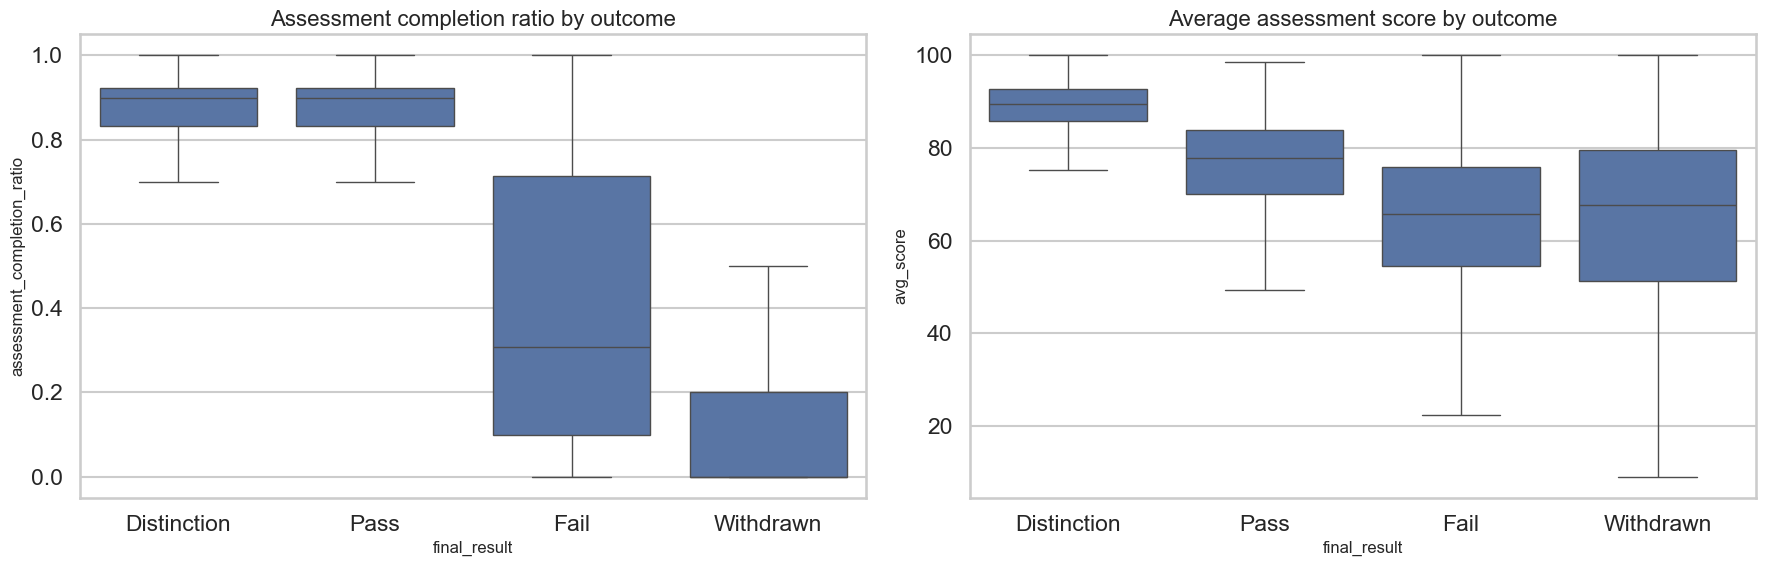

In [34]:
assessment_outcome_summary = (
    eda_base.groupby("final_result", observed=True)
    .agg(
        assessment_submission_rate=("has_assessment_submission", "mean"),
        median_completion_ratio=("assessment_completion_ratio", "median"),
        mean_completion_ratio=("assessment_completion_ratio", "mean"),
        median_avg_score=("avg_score", "median"),
        mean_avg_score=("avg_score", "mean"),
        median_weighted_score_sum=("weighted_score_sum", "median"),
        median_late_rate_non_exam=("late_submission_rate_non_exam", "median"),
    )
    .assign(assessment_submission_rate=lambda df: df["assessment_submission_rate"] * 100)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=eda_base, x="final_result", y="assessment_completion_ratio", order=OUTCOME_ORDER, ax=axes[0], showfliers=False)
axes[0].set_title("Assessment completion ratio by outcome")
axes[0].set_xlabel("final_result")
axes[0].set_ylabel("assessment_completion_ratio")

sns.boxplot(data=eda_base, x="final_result", y="avg_score", order=OUTCOME_ORDER, ax=axes[1], showfliers=False)
axes[1].set_title("Average assessment score by outcome")
axes[1].set_xlabel("final_result")
axes[1].set_ylabel("avg_score")

plt.tight_layout()
display(assessment_outcome_summary)

,final_result,assessment_type,avg_submission_delay,median_submission_delay,late_share
0,Distinction,CMA,-46.806,-14.000,41.939
1,Distinction,Exam,162.462,234.000,69.353
2,Distinction,TMA,-2.630,-1.000,7.658
3,Pass,CMA,-38.472,-6.000,42.257
4,Pass,Exam,124.733,230.000,54.700
5,Pass,TMA,-0.975,-1.000,14.939
6,Fail,CMA,-30.114,2.000,60.119
7,Fail,Exam,136.004,234.000,59.287
8,Fail,TMA,-0.768,0.000,24.886
9,Withdrawn,CMA,-33.779,2.000,74.211


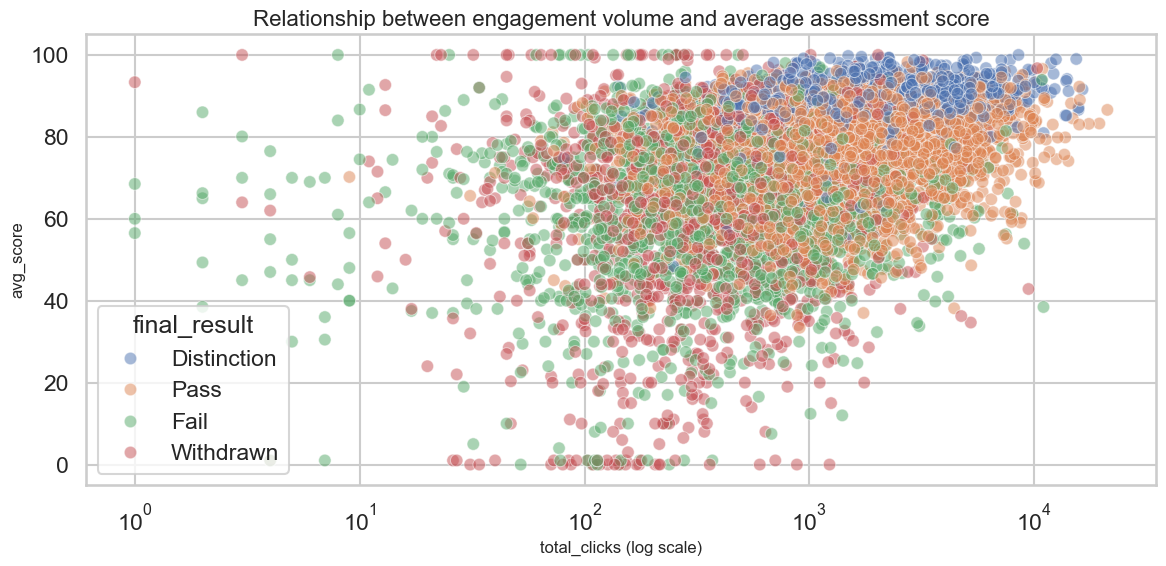

In [35]:
scatter_cols = ["total_clicks", "avg_score", "final_result", "assessment_completion_ratio"]
scatter_df = eda_base[scatter_cols].dropna()
if len(scatter_df) > 8_000:
    scatter_df = scatter_df.sample(8_000, random_state=42)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=scatter_df,
    x="total_clicks",
    y="avg_score",
    hue="final_result",
    hue_order=OUTCOME_ORDER,
    alpha=0.5,
)
plt.xscale("log")
plt.title("Relationship between engagement volume and average assessment score")
plt.xlabel("total_clicks (log scale)")
plt.ylabel("avg_score")
plt.tight_layout()

delay_summary = (
    assessment_perf_corrected.groupby(["final_result", "assessment_type"], observed=True)
    .agg(
        avg_submission_delay=("submission_delay", "mean"),
        median_submission_delay=("submission_delay", "median"),
        late_share=("is_late", "mean"),
    )
    .assign(late_share=lambda df: df["late_share"] * 100)
    .reset_index()
)

display(delay_summary)

**Assessment interpretation**

- Assessment coverage is nearly universal for successful learners but much weaker for unsuccessful ones. The assessment submission rate is 100.0% for `Distinction` and only 46.2% for `Withdrawn`.
- Completion is a major separator: median assessment completion ratio is 0.90 for `Distinction`, 0.90 for `Pass`, 0.31 for `Fail`, and 0.00 for `Withdrawn`.
- Score quality also separates groups strongly. Median learner-level average score falls from 89.4 (`Distinction`) to 65.8 (`Fail`).
- Continuous-assessment delay should be treated carefully by type, especially because exam timing behaves differently from TMA/CMA timing.
- Assessment completion ratio, weighted score, and non-exam lateness belong near the top of the feature-engineering priority list.


## 9. Registration and persistence

Look at registration lead time, withdrawal timing, and persistence patterns that matter for the at-risk storyline.


,median_registration_lead,mean_registration_lead,unregistration_rate
final_result,,,
Distinction,52.000,65.642,0.000
Pass,53.000,66.707,0.000
Fail,50.000,62.807,0.128
Withdrawn,67.000,78.369,98.878


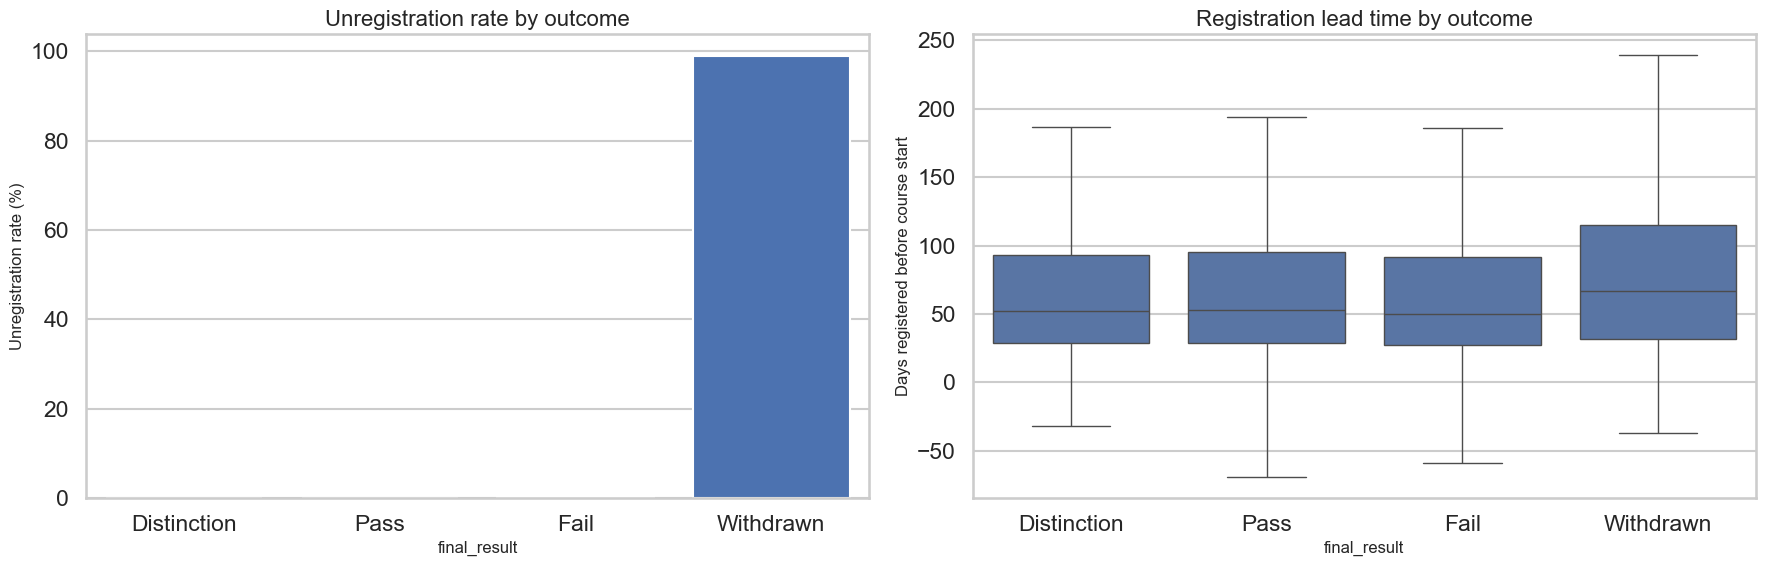

In [36]:
registration_outcome_summary = (
    eda_base.groupby("final_result", observed=True)
    .agg(
        median_registration_lead=("registered_before_start_days", "median"),
        mean_registration_lead=("registered_before_start_days", "mean"),
        unregistration_rate=("date_unregistration", lambda s: s.notna().mean()),
    )
    .assign(unregistration_rate=lambda df: df["unregistration_rate"] * 100)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    x=registration_outcome_summary.index,
    y=registration_outcome_summary["unregistration_rate"].values,
    order=OUTCOME_ORDER,
    ax=axes[0],
)
axes[0].set_title("Unregistration rate by outcome")
axes[0].set_xlabel("final_result")
axes[0].set_ylabel("Unregistration rate (%)")

sns.boxplot(
    data=eda_base,
    x="final_result",
    y="registered_before_start_days",
    order=OUTCOME_ORDER,
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("Registration lead time by outcome")
axes[1].set_xlabel("final_result")
axes[1].set_ylabel("Days registered before course start")

plt.tight_layout()
display(registration_outcome_summary)

,count,mean,std,min,10%,25%,50%,75%,90%,max
date_unregistration,"10,042.000",50.190,82.038,-317.000,-36.900,-1.000,28.000,109.000,170.000,444.000


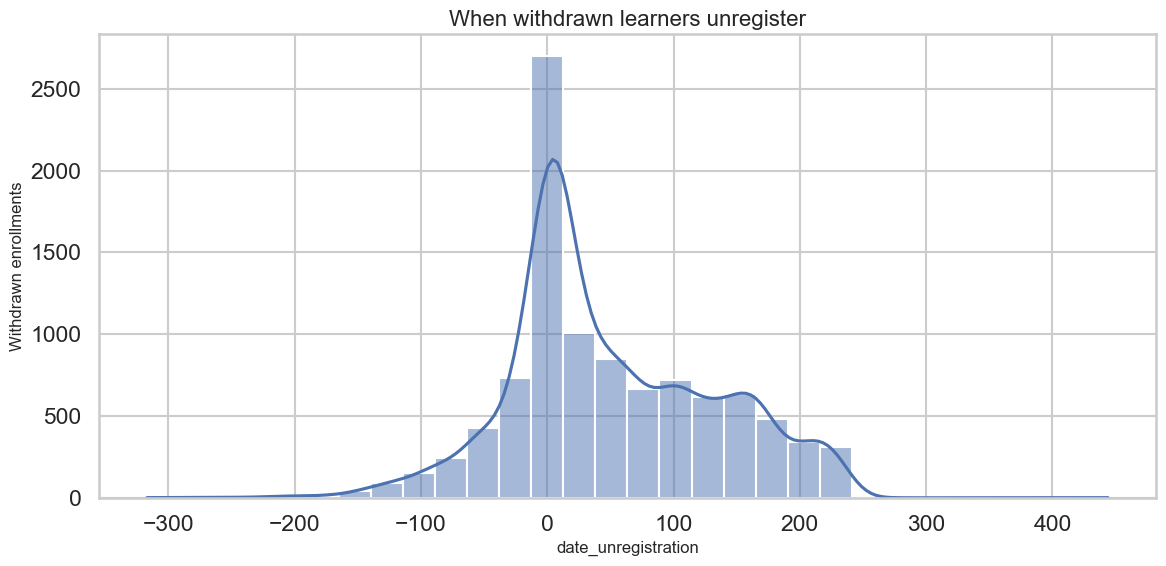

In [37]:
withdrawn_subset = eda_base.loc[eda_base["final_result"].eq("Withdrawn") & eda_base["date_unregistration"].notna()].copy()

plt.figure(figsize=(12, 6))
sns.histplot(withdrawn_subset["date_unregistration"], bins=30, kde=True)
plt.title("When withdrawn learners unregister")
plt.xlabel("date_unregistration")
plt.ylabel("Withdrawn enrollments")
plt.tight_layout()

withdrawn_timing_summary = withdrawn_subset["date_unregistration"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame().T
display(withdrawn_timing_summary)

In [38]:
withdrawn_before_start = (withdrawn_subset["date_unregistration"] < 0).mean() * 100
withdrawn_within_30 = (withdrawn_subset["date_unregistration"] <= 30).mean() * 100


**Persistence interpretation**

- Unregistration is almost exclusive to `Withdrawn` enrollments: the unregistration rate is 98.9% for `Withdrawn` and effectively zero for successful outcomes.
- The median unregistration point for withdrawn learners is day 28, with 26.4% unregistering before the presentation starts and 50.8% leaving by day 30.
- This makes persistence a timing problem as much as an outcome problem: many withdrawals occur very early, which strengthens the case for week-1 to week-4 monitoring.
- Registration lead time is informative but weaker than engagement and assessment signals; it is better treated as a contextual rather than primary predictor.


## 10. At-risk signal shortlist

Keep only the most actionable comparisons: direct at-risk vs non at-risk gaps, univariate signal strength, and simple feature gradients.


In [39]:
risk_compare = (
    eda_base.groupby("at_risk_label", observed=True)
    .agg(
        enrollments=("id_student", "size"),
        median_total_clicks=("total_clicks", "median"),
        median_clicks_14d=("clicks_14d", "median"),
        median_clicks_30d=("clicks_30d", "median"),
        median_total_active_days=("total_active_days", "median"),
        median_active_days_30=("active_days_30", "median"),
        median_completion_ratio=("assessment_completion_ratio", "median"),
        median_avg_score=("avg_score", "median"),
        median_recency_from_end=("engagement_recency_from_end", "median"),
        pre_start_engagement_rate=("engaged_pre_start", "mean"),
        early_active_14d_rate=("early_active_flag_14d", "mean"),
        unregistration_rate=("date_unregistration", lambda s: s.notna().mean()),
    )
    .assign(
        pre_start_engagement_rate=lambda df: df["pre_start_engagement_rate"] * 100,
        early_active_14d_rate=lambda df: df["early_active_14d_rate"] * 100,
        unregistration_rate=lambda df: df["unregistration_rate"] * 100,
    )
)

display(risk_compare)

,enrollments,median_total_clicks,median_clicks_14d,median_clicks_30d,median_total_active_days,median_active_days_30,median_completion_ratio,median_avg_score,median_recency_from_end,pre_start_engagement_rate,early_active_14d_rate,unregistration_rate
at_risk_label,,,,,,,,,,,,
At-risk,17208,175.000,25.000,71.000,12.000,5.000,0.143,66.600,200.000,61.791,69.119,58.409
Non at-risk,15385,"1,425.000",112.000,253.000,82.000,13.000,0.900,80.250,11.000,85.642,95.444,0.000


,feature,effective_auc,raw_auc,direction
7,engagement_recency_from_end,0.945,0.945,Higher values indicate higher risk
0,assessment_completion_ratio,0.942,0.058,Lower values indicate higher risk
1,active_duration_days,0.942,0.058,Lower values indicate higher risk
2,total_active_days,0.899,0.101,Lower values indicate higher risk
3,weighted_score_sum,0.896,0.104,Lower values indicate higher risk
4,total_clicks,0.875,0.125,Lower values indicate higher risk
5,avg_score,0.845,0.155,Lower values indicate higher risk
6,clicks_60d,0.767,0.233,Lower values indicate higher risk
8,active_days_30,0.752,0.248,Lower values indicate higher risk
9,clicks_30d,0.737,0.263,Lower values indicate higher risk


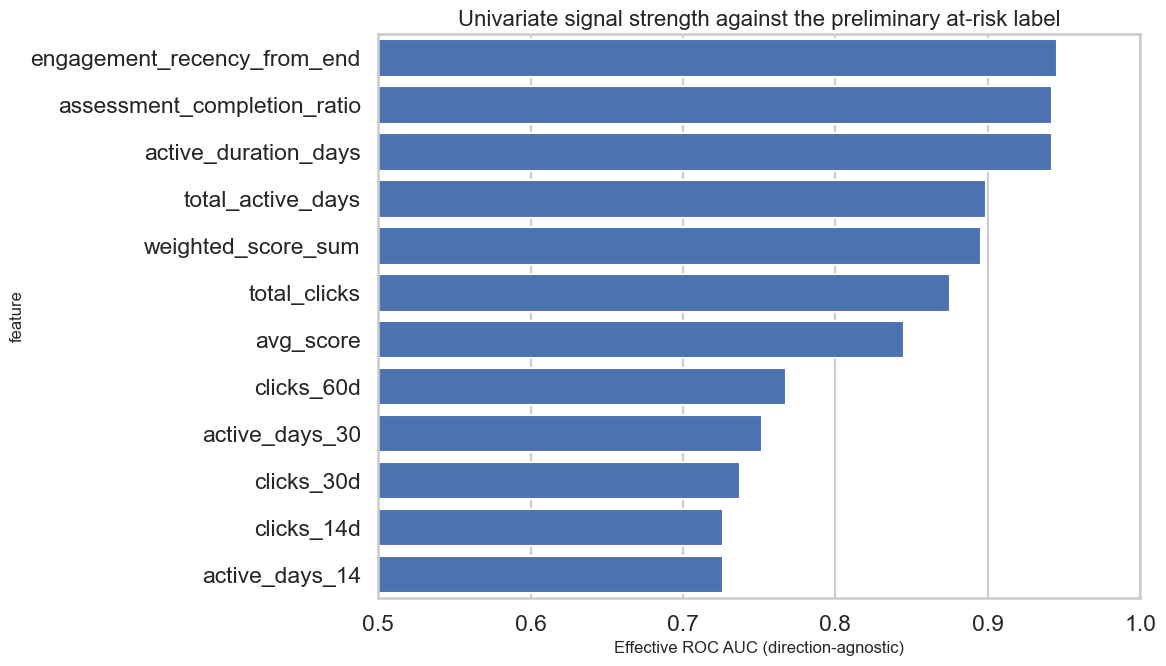

In [40]:
ranking_features = [
    "assessment_completion_ratio",
    "active_duration_days",
    "total_active_days",
    "weighted_score_sum",
    "total_clicks",
    "avg_score",
    "clicks_60d",
    "engagement_recency_from_end",
    "active_days_30",
    "clicks_30d",
    "clicks_14d",
    "active_days_14",
    "clicks_per_active_day",
    "pre_start_clicks",
    "num_of_prev_attempts",
    "studied_credits",
    "registered_before_start_days",
]
ranking_features = ensure_columns(eda_base, ranking_features)

auc_rows = []
y = eda_base["at_risk_eda"]

for feature in ranking_features:
    s = eda_base[feature].fillna(0)
    if s.nunique() < 2:
        continue
    auc = roc_auc_score(y, s)
    effective_auc = max(auc, 1 - auc)
    direction = "Higher values indicate higher risk" if auc >= 0.5 else "Lower values indicate higher risk"
    auc_rows.append(
        {
            "feature": feature,
            "effective_auc": effective_auc,
            "raw_auc": auc,
            "direction": direction,
        }
    )

auc_df = pd.DataFrame(auc_rows).sort_values("effective_auc", ascending=False)
display(auc_df)

plt.figure(figsize=(12, 7))
sns.barplot(data=auc_df.head(12), x="effective_auc", y="feature")
plt.title("Univariate signal strength against the preliminary at-risk label")
plt.xlabel("Effective ROC AUC (direction-agnostic)")
plt.ylabel("feature")
plt.xlim(0.5, 1.0)
plt.tight_layout()

quintile,Q1 (lowest),Q2,Q3,Q4,Q5 (highest)
feature,,,,,
assessment_completion_ratio,99.954,99.279,42.553,11.982,10.216
avg_score,77.094,48.800,32.888,25.019,18.592
clicks_14d,86.716,60.832,47.891,39.537,29.008
engagement_recency_from_end,7.915,14.959,41.433,99.739,99.939
total_clicks,99.187,78.460,47.231,27.478,11.628


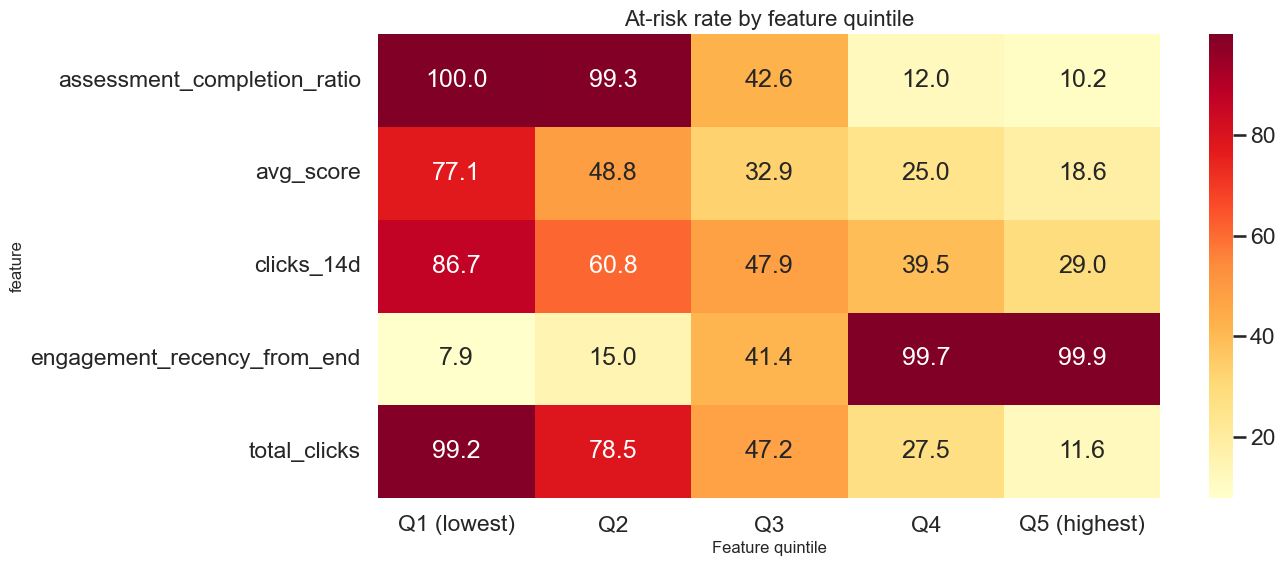

In [41]:
gradient_features = ["total_clicks", "clicks_14d", "assessment_completion_ratio", "avg_score", "engagement_recency_from_end"]
gradient_rows = []

for feature in gradient_features:
    tmp = eda_base[[feature, "at_risk_eda"]].dropna().copy()
    if tmp[feature].nunique() < 5:
        continue
    tmp["quintile"] = pd.qcut(
        tmp[feature].rank(method="first"),
        q=5,
        labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"],
    )
    grad = (
        tmp.groupby("quintile", observed=True)["at_risk_eda"]
        .mean()
        .mul(100)
        .rename("at_risk_rate")
        .reset_index()
    )
    grad["feature"] = feature
    gradient_rows.append(grad)

gradient_df = pd.concat(gradient_rows, ignore_index=True)
gradient_pivot = gradient_df.pivot(index="feature", columns="quintile", values="at_risk_rate")

plt.figure(figsize=(14, 6))
sns.heatmap(gradient_pivot, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("At-risk rate by feature quintile")
plt.xlabel("Feature quintile")
plt.ylabel("feature")
plt.tight_layout()

display(gradient_pivot)

In [42]:
top_signal = auc_df.iloc[0]


**Preliminary at-risk interpretation**

- The strongest single-variable signal in this EDA is `engagement_recency_from_end` with an effective ROC AUC of 0.945.
- At-risk learners have much lower early engagement: median `clicks_14d` are 25 versus 112 for non at-risk learners.
- They also show much weaker assessment discipline: median completion ratio is 0.14 versus 0.90.
- Recency is a strong persistence signal: the median distance from last activity to course end is 200 days for at-risk learners versus 11 for non at-risk learners.
- For recall-oriented modeling, early-window engagement, assessment completion, and disengagement timing should be treated as first-class features, not optional extras.


## 11. Feature engineering handoff

Translate the strongest EDA evidence into candidate features for the next notebook.


In [43]:
feature_handoff = pd.DataFrame([
    {
        "feature_name": "total_clicks",
        "business_meaning": "Overall engagement volume across the presentation",
        "likely_source_tables": "student_vle_summary, student_vle_clean",
        "why_it_matters": "Strongly separates successful and unsuccessful learners; captures general participation intensity.",
        "feature_family": "Engagement",
    },
    {
        "feature_name": "total_active_days",
        "business_meaning": "How many distinct days the learner was active",
        "likely_source_tables": "student_vle_clean",
        "why_it_matters": "More stable than click volume alone and highly discriminative for persistence.",
        "feature_family": "Engagement / Persistence",
    },
    {
        "feature_name": "clicks_per_active_day",
        "business_meaning": "Average click intensity on days when the learner is active",
        "likely_source_tables": "student_vle_clean",
        "why_it_matters": "Distinguishes heavy but concentrated usage from sustained moderate usage.",
        "feature_family": "Engagement Intensity",
    },
    {
        "feature_name": "pre_start_clicks",
        "business_meaning": "Engagement before the formal course start",
        "likely_source_tables": "student_vle_clean",
        "why_it_matters": "Signals preparation and early self-regulation; lower values are associated with risk.",
        "feature_family": "Timing / Engagement",
    },
    {
        "feature_name": "clicks_14d / clicks_30d / clicks_60d",
        "business_meaning": "Early engagement windows for progressive monitoring",
        "likely_source_tables": "student_vle_clean",
        "why_it_matters": "Useful for early-warning models and intervention triggers at multiple time horizons.",
        "feature_family": "Timing / Early Warning",
    },
    {
        "feature_name": "active_days_14 / active_days_30",
        "business_meaning": "Breadth of early participation over time",
        "likely_source_tables": "student_vle_clean",
        "why_it_matters": "Captures sustained rhythm better than raw click counts alone.",
        "feature_family": "Timing / Engagement Stability",
    },
    {
        "feature_name": "engagement_recency_from_end",
        "business_meaning": "How long before the course end the learner stops interacting",
        "likely_source_tables": "student_vle_summary, courses",
        "why_it_matters": "Strong persistence signal; large values often indicate disengagement and withdrawal risk.",
        "feature_family": "Persistence / Timing",
    },
    {
        "feature_name": "active_duration_days",
        "business_meaning": "Span between first and last observed activity",
        "likely_source_tables": "student_vle_summary",
        "why_it_matters": "Captures whether engagement is sustained across the presentation or collapses early.",
        "feature_family": "Persistence",
    },
    {
        "feature_name": "assessment_completion_ratio",
        "business_meaning": "Share of available assessments actually submitted",
        "likely_source_tables": "assessments_clean, student_assessment_clean",
        "why_it_matters": "One of the strongest practical predictors of both academic success and risk.",
        "feature_family": "Assessment Discipline",
    },
    {
        "feature_name": "avg_score / weighted_score_sum",
        "business_meaning": "Quality of submitted assessment performance",
        "likely_source_tables": "student_assessment_clean, assessments_clean",
        "why_it_matters": "Separates low-performing learners from high-performing learners even after participation is accounted for.",
        "feature_family": "Assessment Performance",
    },
    {
        "feature_name": "late_submission_rate_non_exam",
        "business_meaning": "Share of non-exam assessments submitted after the due date",
        "likely_source_tables": "student_assessment_clean, assessments_clean",
        "why_it_matters": "Useful proxy for time management and assessment discipline.",
        "feature_family": "Assessment Timing",
    },
    {
        "feature_name": "registered_before_start_days",
        "business_meaning": "Lead time between registration and course start",
        "likely_source_tables": "student_registration_clean",
        "why_it_matters": "Contextual persistence signal; may help distinguish last-minute joiners from prepared starters.",
        "feature_family": "Timing / Context",
    },
    {
        "feature_name": "withdrawal_before_end",
        "business_meaning": "Whether the learner explicitly unregisters before presentation end",
        "likely_source_tables": "student_registration_clean, courses",
        "why_it_matters": "Critical persistence indicator and useful supervision target for dropout-focused analysis.",
        "feature_family": "Persistence",
    },
    {
        "feature_name": "num_of_prev_attempts",
        "business_meaning": "Prior retake history",
        "likely_source_tables": "student_info_clean or raw studentInfo",
        "why_it_matters": "Repeated prior attempts show substantially higher risk and may require differentiated support.",
        "feature_family": "Learner Background",
    },
    {
        "feature_name": "studied_credits",
        "business_meaning": "Concurrent study load",
        "likely_source_tables": "student_info_clean or raw studentInfo",
        "why_it_matters": "Heavier credit loads are more withdrawal-heavy and may interact with engagement capacity.",
        "feature_family": "Learner Background / Workload",
    },
    {
        "feature_name": "course_context_features",
        "business_meaning": "Module, presentation, and course-specific baseline conditions",
        "likely_source_tables": "courses, student_registration_clean, raw/clean student info",
        "why_it_matters": "Course setting materially changes baseline risk and should be represented explicitly.",
        "feature_family": "Course Context",
    },
])

display(feature_handoff)


,feature_name,business_meaning,likely_source_tables,why_it_matters,feature_family
0,total_clicks,Overall engagement volume across the presentation,"student_vle_summary, student_vle_clean",Strongly separates successful and unsuccessful...,Engagement
1,total_active_days,How many distinct days the learner was active,student_vle_clean,More stable than click volume alone and highly...,Engagement / Persistence
2,clicks_per_active_day,Average click intensity on days when the learn...,student_vle_clean,Distinguishes heavy but concentrated usage fro...,Engagement Intensity
3,pre_start_clicks,Engagement before the formal course start,student_vle_clean,Signals preparation and early self-regulation;...,Timing / Engagement
4,clicks_14d / clicks_30d / clicks_60d,Early engagement windows for progressive monit...,student_vle_clean,Useful for early-warning models and interventi...,Timing / Early Warning
5,active_days_14 / active_days_30,Breadth of early participation over time,student_vle_clean,Captures sustained rhythm better than raw clic...,Timing / Engagement Stability
6,engagement_recency_from_end,How long before the course end the learner sto...,"student_vle_summary, courses",Strong persistence signal; large values often ...,Persistence / Timing
7,active_duration_days,Span between first and last observed activity,student_vle_summary,Captures whether engagement is sustained acros...,Persistence
8,assessment_completion_ratio,Share of available assessments actually submitted,"assessments_clean, student_assessment_clean",One of the strongest practical predictors of b...,Assessment Discipline
9,avg_score / weighted_score_sum,Quality of submitted assessment performance,"student_assessment_clean, assessments_clean",Separates low-performing learners from high-pe...,Assessment Performance


**Feature engineering guidance**

- Build both full-course features and time-windowed early-warning versions wherever possible.
- Normalize or winsorize highly skewed engagement variables before distance-based segmentation or linear modeling.
- Keep interpretable raw features alongside transformed versions so Power BI and report outputs remain explainable.


## 12. Power BI handoff

Map the strongest insights to dashboard pages and visuals so the BI layer tells one coherent story.


In [44]:
power_bi_handoff = pd.DataFrame([
    {
        "dashboard_page": "Executive Overview",
        "recommended_element": "KPI cards",
        "metric_or_visual": "Total enrollments, unique learners, at-risk rate, VLE coverage, assessment coverage, median clicks, mean score",
        "why_it_matters": "Provides immediate scale, risk exposure, and platform-usage context.",
        "suggested_slicers": "code_module, code_presentation",
    },
    {
        "dashboard_page": "Executive Overview",
        "recommended_element": "Outcome bar chart",
        "metric_or_visual": "Distribution of Distinction / Pass / Fail / Withdrawn",
        "why_it_matters": "Frames the full performance problem before drilling into causes.",
        "suggested_slicers": "code_module, code_presentation, age_band",
    },
    {
        "dashboard_page": "Learning Behavior Analytics",
        "recommended_element": "Engagement timeline",
        "metric_or_visual": "7-day rolling clicks per enrollment by final_result",
        "why_it_matters": "Shows where trajectories separate and where intervention windows begin.",
        "suggested_slicers": "code_module, code_presentation, final_result",
    },
    {
        "dashboard_page": "Learning Behavior Analytics",
        "recommended_element": "Heatmap",
        "metric_or_visual": "Median clicks by module-presentation; outcome mix by module",
        "why_it_matters": "Highlights structural differences across course settings.",
        "suggested_slicers": "code_module, code_presentation",
    },
    {
        "dashboard_page": "Learning Behavior Analytics",
        "recommended_element": "Stacked / heatmap resource view",
        "metric_or_visual": "Activity-type mix by outcome group",
        "why_it_matters": "Supports content-level interpretation and recommendation logic.",
        "suggested_slicers": "code_module, code_presentation, at_risk_label",
    },
    {
        "dashboard_page": "Assessment & Persistence",
        "recommended_element": "Boxplots and scatter",
        "metric_or_visual": "Assessment completion ratio, average score, clicks vs score",
        "why_it_matters": "Links behavior to academic output in one view.",
        "suggested_slicers": "assessment_type, code_module, code_presentation",
    },
    {
        "dashboard_page": "Assessment & Persistence",
        "recommended_element": "Withdrawal timing view",
        "metric_or_visual": "Unregistration rate by outcome and histogram of withdrawal timing",
        "why_it_matters": "Makes persistence loss visible and operationally actionable.",
        "suggested_slicers": "code_module, code_presentation, age_band",
    },
    {
        "dashboard_page": "At-Risk Learners",
        "recommended_element": "Comparator cards and table",
        "metric_or_visual": "At-risk vs non at-risk medians for clicks, active days, completion ratio, score, recency",
        "why_it_matters": "Translates model-oriented signals into an understandable operational narrative.",
        "suggested_slicers": "code_module, code_presentation, highest_education, disability",
    },
    {
        "dashboard_page": "At-Risk Learners",
        "recommended_element": "Feature importance proxy",
        "metric_or_visual": "Top EDA-based signals ranked by effective AUC",
        "why_it_matters": "Previews why later risk scores behave the way they do.",
        "suggested_slicers": "module, presentation, learner segment",
    },
])

display(power_bi_handoff)


,dashboard_page,recommended_element,metric_or_visual,why_it_matters,suggested_slicers
0,Executive Overview,KPI cards,"Total enrollments, unique learners, at-risk ra...","Provides immediate scale, risk exposure, and p...","code_module, code_presentation"
1,Executive Overview,Outcome bar chart,Distribution of Distinction / Pass / Fail / Wi...,Frames the full performance problem before dri...,"code_module, code_presentation, age_band"
2,Learning Behavior Analytics,Engagement timeline,7-day rolling clicks per enrollment by final_r...,Shows where trajectories separate and where in...,"code_module, code_presentation, final_result"
3,Learning Behavior Analytics,Heatmap,Median clicks by module-presentation; outcome ...,Highlights structural differences across cours...,"code_module, code_presentation"
4,Learning Behavior Analytics,Stacked / heatmap resource view,Activity-type mix by outcome group,Supports content-level interpretation and reco...,"code_module, code_presentation, at_risk_label"
5,Assessment & Persistence,Boxplots and scatter,"Assessment completion ratio, average score, cl...",Links behavior to academic output in one view.,"assessment_type, code_module, code_presentation"
6,Assessment & Persistence,Withdrawal timing view,Unregistration rate by outcome and histogram o...,Makes persistence loss visible and operational...,"code_module, code_presentation, age_band"
7,At-Risk Learners,Comparator cards and table,"At-risk vs non at-risk medians for clicks, act...",Translates model-oriented signals into an unde...,"code_module, code_presentation, highest_educat..."
8,At-Risk Learners,Feature importance proxy,Top EDA-based signals ranked by effective AUC,Previews why later risk scores behave the way ...,"module, presentation, learner segment"


**Dashboard storyline suggestions**

- Start with outcome scale and at-risk exposure.
- Move into behavioral engagement: volume, timing, and content mix.
- Then connect behavior to assessment completion and persistence.
- Finish with an explicit at-risk view that turns analytics into intervention design.


## 13. Final conclusion

Close with the strongest findings and the clearest next actions for the project.


### Strongest EDA insights
1. The rebuilt master table preserves **32,593 enrollment records**, correcting an important outcome-grain issue in the processed profile table.
2. Preliminary at-risk outcomes (`Fail` or `Withdrawn`) account for **52.8%** of enrollments, so the project is solving a large and operationally important problem.
3. Outcome patterns differ sharply by course context: module **CCC** has the highest at-risk rate (**62.2%**) while **AAA** has the lowest (**29.0%**).
4. Engagement volume and persistence matter immediately. Median total clicks range from **89** for `Withdrawn` to **1,896** for `Distinction`.
5. Early behavior is already informative: median `clicks_14d` are **156** for `Distinction` and only **12** for `Withdrawn`.
6. Assessment completion is one of the clearest separators: median completion ratio is **0.90** for `Distinction`, **0.90** for `Pass`, **0.31** for `Fail`, and **0.00** for `Withdrawn`.
7. Withdrawal is often early. The median unregistration day among withdrawn learners is **28**, and many withdrawals happen before or soon after course start.
8. VLE activity type matters, not just VLE volume. At-risk learners over-index on lighter-navigation behavior, while successful learners devote more interaction share to learning-content and discussion-oriented resources.
9. The strongest practical feature candidates from EDA are **engagement_recency_from_end, assessment_completion_ratio, active_duration_days, total_active_days, weighted_score_sum**, plus complementary background and course-context variables.
10. Background variables are useful but secondary: prior attempts, disability, education, and study load all matter, but behavior and assessment discipline are much stronger separators than gender alone.

### What this implies for later project stages
- **Segmentation** should combine learner background with engagement rhythm, assessment discipline, and course context, rather than relying on demographics alone.
- **Recommendation design** should prioritize early engagement nudges, structured content pathways, and intervention on low-value navigation-heavy behavior.
- **At-risk modeling** should emphasize recall-sensitive early-warning features built at 14, 30, and 60 days, plus persistence and completion signals.

### Key limitations and caveats
- The preliminary at-risk label is intentionally broad and should not be treated as the final supervised target without project-specific refinement.
- Some processed tables required integrity checks because enrollment-level outcomes can be misassigned if joins are performed at the student-only grain.
- Click counts are behavior proxies, not direct learning-quality measures; they gain value when combined with timing, resource type, and assessment evidence.

### Recommended next steps
1. Build a clean feature store in `04_feature_engineering.ipynb` using the candidate features identified here.
2. Create learner segments that blend engagement intensity, persistence, and assessment discipline in `05_segmentation_recommendation.ipynb`.
3. Build early-warning models in `06_at_risk_modeling.ipynb` with emphasis on recall, calibration, and intervention usefulness.
4. Translate the strongest KPI, timeline, and comparison views into Power BI pages using the handoff section above.
